# Business Understanding

### BO1 : Detect potential health risks early

* Use real-world customer interactions and feedback to identify harmful patterns that individual users or practitioners might miss.

* Prevent adverse effects by spotting problematic supplement combinations, over consumption, or ingredient sensitivities before they affect many clients.

### DSO1 : Implement an AI-Powered Safety Monitoring System

* Deploy an AI system that analyzes conversations, reviews, and feedback about supplements and care products.

* Detect unusual patterns such as reported side effects, product interactions, or region-specific issues.

* Provide alerts to the company to act proactively and protect customer health.
*******************
### BO2: Cut training and operational costs

* Replace expensive in-person sessions and printed materials with digital alternatives.

* Improve training quality while eliminating travel and material expenditures.

### DSO2: Launch a Virtual Training and Interaction Platform

* Establish a digital academy featuring AI patient simulations and interactive online modules for global, 24/7 access.

* Eliminate travel and printing costs through this scalable solution.
*******************
### BO3: Eliminate Compliance Risks in Medical Presentations 
* Stop regulatory fines and ethical breaches by catching non-compliant content before it's shared with doctors and pharmacists. 
* Build trust with healthcare authorities and HCPs by guaranteeing that all communicated information is accurate, approved, and patient-safe. 
### DSO3: Implement an AI-Powered Real-Time Risk Scoring Engine 
* Deploy a system that scans every automated presentation in all supported languages (FR, EN, AR, ES) for compliance deviations, missing mandatory safety information, and unsupported claims. 
* Provide a visual risk dashboard for supervisors, generate audit trails for every presentation, and block high-risk content from being delivered until corrected.
*******************
### BO4: Prevent Loss of Key Healthcare Professionals 
* Identify doctors and pharmacists who may stop prescribing or engaging with your products before they do. 
* Use interaction data to find at-risk relationships early, allowing you to act before losing important partners. 
### DSO4: Deploy an AI-Powered HCP Engagement & Churn Predictor 
* Implement a smart system that analyzes delegate visit reports, CRM history, and ALIA interaction data to calculate an engagement score for each healthcare professional. 
* Predict which HCPs are likely to reduce prescriptions or become inactive, and alert the field team with personalized re-engagement strategies. 

# Data Acquisition and Understanding

## DSO1: Implement an AI-Powered Safety Monitoring System

### NIH Dietary Supplements

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
from datetime import datetime

In [4]:
client = MongoClient("mongodb://localhost:27017/")
db = client["AvatarDB"]
collection = db["nih_raw_products"]

In [6]:
cursor = collection.find()
documents = list(cursor)

len(documents)

214780

In [8]:
documents[0].keys()

dict_keys(['_id', 'dsld_id', 'product_info', 'label_statements', 'supplement_facts', 'ingestion_metadata'])

In [10]:
products = []

for doc in documents:
    p = doc["product_info"]
    products.append({
        "dsld_id": doc["dsld_id"],
        "product_name": p.get("product_name"),
        "brand_name": p.get("brand_name"),
        "market_status": p.get("market_status"),
        "product_type": p.get("product_type_[langual]"),
        "supplement_form": p.get("supplement_form_[langual]"),
        "serving_size": p.get("serving_size"),
        "suggested_use": p.get("suggested_use"),
        "date_entered": p.get("date_entered_into_dsld")
    })

df_products = pd.DataFrame(products)
df_products.head()

,dsld_id,product_name,brand_name,market_status,product_type,supplement_form,serving_size,suggested_use,date_entered
0,542,B-2 100 mg,Vitamin World,On Market,Vitamin [A1302],Tablet or Pill [E0155],1 Tablet(s),DIRECTIONS: For adults; take one (1) to two (2...,2011-11-25
1,543,B-6 100 mg,Vitamin World,Off Market,Vitamin [A1302],Tablet or Pill [E0155],1 Tablet(s),DIRECTIONS: For adults; take one (1) tablet da...,2011-11-25
2,544,C-1000 mg With Protective Bioflavonoids And Wi...,Vitamin World,Off Market,Other Combinations [A1325],Other (e.g. tea bag) [E0172],1 Caplet(s),DIRECTIONS: For adults; take one (1) to two (2...,2011-11-25
3,545,Niacin 250 mg,Vitamin World,On Market,Vitamin [A1302],Tablet or Pill [E0155],1 Tablet(s),DIRECTIONS: For adults; take one (1) tablet da...,2011-11-25
4,546,Niacinamide 500 mg,Vitamin World,On Market,Vitamin [A1302],Tablet or Pill [E0155],1 Tablet(s),DIRECTIONS: For adults; take one (1) tablet da...,2011-10-26


In [12]:
labels = []

for doc in documents:
    for stmt in doc.get("label_statements", []):
        labels.append({
            "dsld_id": doc["dsld_id"],
            "statement_type": stmt.get("statement_type"),
            "statement": stmt.get("statement")
        })

df_labels = pd.DataFrame(labels)
df_labels.head()

,dsld_id,statement_type,statement
0,542,Branding Statement(s),Â©2008 Vitamin World Inc.
1,542,Statement of Identity,*These statements have not been evaluated by t...
2,542,Formulation,No Artificial Color or Flavor No Preservatives...
3,542,Precautions,WARNING: If you are pregnant nursing or taking...
4,542,Product/Version Code,PROD. #640 B640 04D


In [14]:
facts = []

for doc in documents:
    for fact in doc.get("supplement_facts", []):
        facts.append({
            "dsld_id": doc["dsld_id"],
            "ingredient": fact.get("ingredient"),
            "category": fact.get("dsld_ingredient_categories"),
            "amount": fact.get("amount_per_serving"),
            "unit": fact.get("amount_per_serving_unit"),
            "daily_value": fact.get("%_daily_value_per_serving")
        })

df_facts = pd.DataFrame(facts)
df_facts.head()

,dsld_id,ingredient,category,amount,unit,daily_value
0,542,Riboflavin,vitamin,100,mg,5882
1,543,Vitamin B6,vitamin,100,mg,5000
2,544,Vitamin C,vitamin,1000,mg,1667
3,544,Citrus Bioflavonoids,non-nutrient/non-botanical,25,mg,NaN
4,544,Rose Hips,botanical,20,mg,NaN


In [16]:
print("Products:", df_products.shape)
print("Label Statements:", df_labels.shape)
print("Supplement Facts:", df_facts.shape)

Products: (214780, 9)
Label Statements: (1467219, 3)
Supplement Facts: (2020130, 6)


In [18]:
df_products["dsld_id"].nunique()

214780

In [20]:
ingredients_per_product = (
    df_facts.groupby("dsld_id")["ingredient"]
    .count()
)

ingredients_per_product.describe()

count    214768.000000
mean          9.406094
std          14.104840
min           1.000000
25%           1.000000
50%           5.000000
75%          12.000000
max         355.000000
Name: ingredient, dtype: float64

In [22]:
df_facts.isnull().sum().sort_values(ascending=False)

daily_value    1312894
amount          609924
unit            566396
ingredient           2
dsld_id              0
category             0
dtype: int64

In [24]:
import re

def has_non_ascii(text):
    return bool(re.search(r"[^\x00-\x7F]", str(text)))

df_labels["has_non_ascii"] = df_labels["statement"].apply(has_non_ascii)

df_labels["has_non_ascii"].value_counts()

has_non_ascii
False    1431597
True       35622
Name: count, dtype: int64

In [26]:
df_labels[df_labels["has_non_ascii"] == True][
    ["statement_type", "statement"]
].head(5)

,statement_type,statement
0,Branding Statement(s),Â©2008 Vitamin World Inc.
9,Branding Statement(s),Â©2008 Vitamin World Inc.
16,Branding Statement(s),Â©2011 Vitamin World Inc.
23,Branding Statement(s),Â©2008 Vitamin World Inc.
30,Branding Statement(s),Â©2010 Vitamin World Inc.


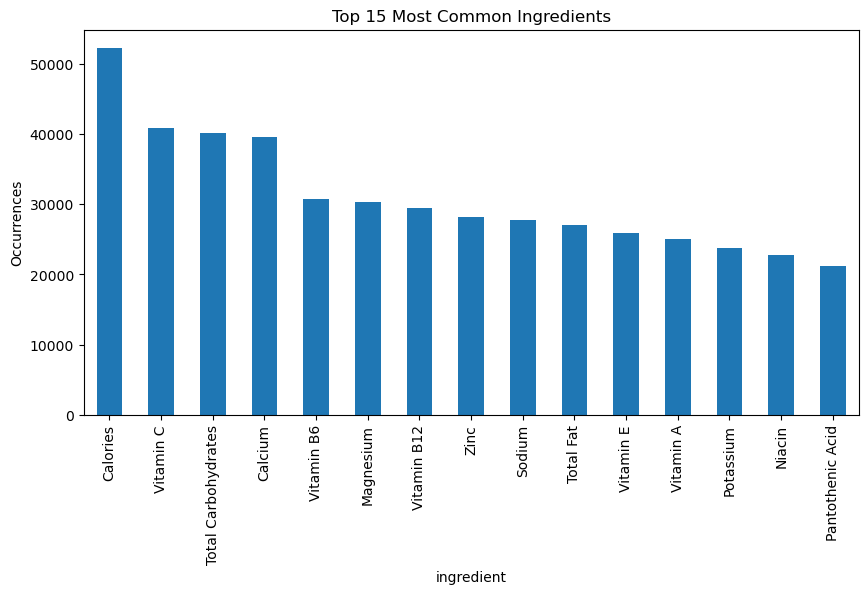

In [28]:
top_ingredients = df_facts["ingredient"].value_counts().head(15)

top_ingredients.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 15 Most Common Ingredients"
)

plt.ylabel("Occurrences")
plt.show()

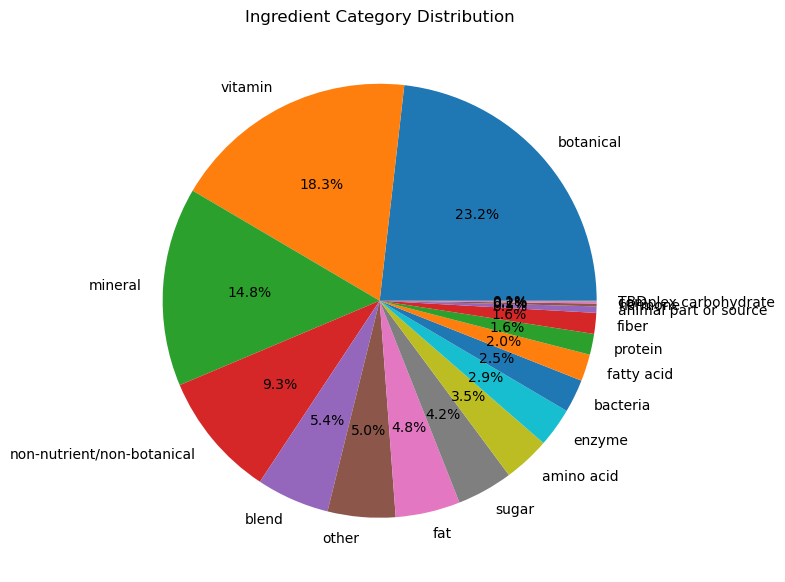

In [30]:
df_facts["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,8),
    title="Ingredient Category Distribution"
)

plt.ylabel("")
plt.show()

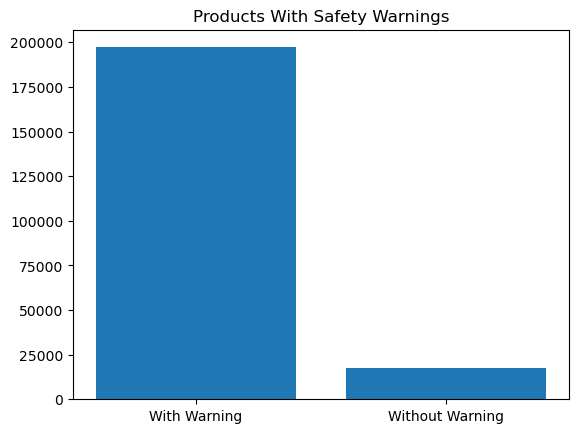

In [32]:
warnings = df_labels[df_labels["statement_type"] == "Precautions"]

products_with_warning = warnings["dsld_id"].nunique()
total_products = df_products["dsld_id"].nunique()

plt.bar(
    ["With Warning", "Without Warning"],
    [products_with_warning, total_products - products_with_warning]
)

plt.title("Products With Safety Warnings")
plt.show()

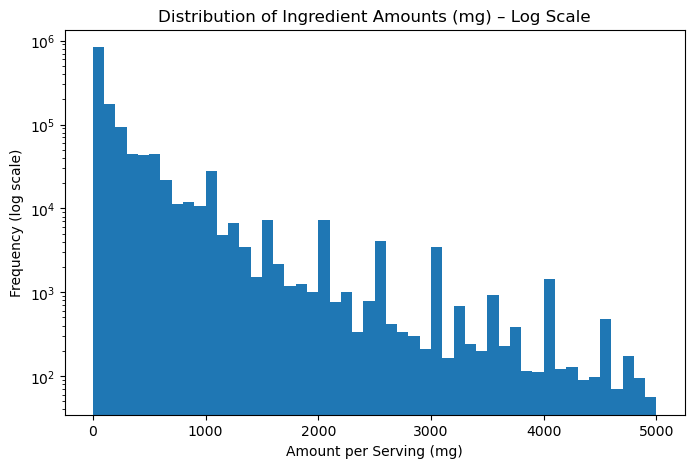

In [34]:
df_facts["amount"] = pd.to_numeric(df_facts["amount"], errors="coerce")

# Keep only realistic values (domain knowledge)
df_amounts_clean = df_facts[
    (df_facts["amount"] > 0) &
    (df_facts["amount"] < 5000)  # 5g upper bound
]
plt.figure(figsize=(8,5))
plt.hist(df_amounts_clean["amount"], bins=50, log=True)
plt.title("Distribution of Ingredient Amounts (mg) – Log Scale")
plt.xlabel("Amount per Serving (mg)")
plt.ylabel("Frequency (log scale)")
plt.show()

In [36]:
df_facts["ingredient_clean"] = (
    df_facts["ingredient"]
    .fillna("")
    .astype(str)
    .str.lower()
    .apply(lambda x: re.sub(r"[^\w\s]", "", x))
)

In [38]:
df_facts["is_blend"] = df_facts["ingredient_clean"].str.contains("blend", na=False)

blend_flag = (
    df_facts.groupby("dsld_id")["is_blend"]
    .any()
    .reset_index()
)

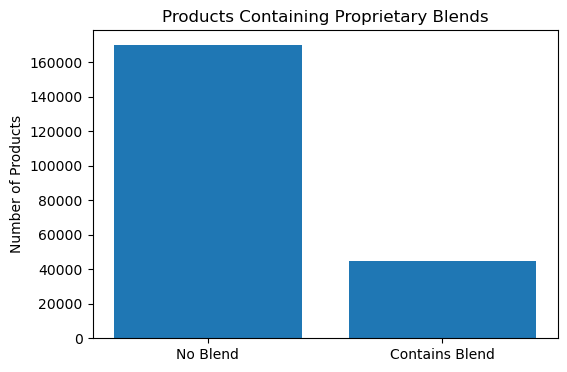

In [40]:
blend_counts = blend_flag["is_blend"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    ["No Blend", "Contains Blend"],
    [blend_counts.get(False, 0), blend_counts.get(True, 0)]
)
plt.title("Products Containing Proprietary Blends")
plt.ylabel("Number of Products")
plt.show()

### What Is a Proprietary Blend?

A proprietary blend refers to a group of ingredients combined under a single label,
where the total quantity is disclosed but the individual ingredient amounts are not.
While legally permitted, proprietary blends reduce transparency and make it difficult
to assess ingredient-level safety, dosage, and interactions.

For this reason, the presence of blends is treated as a risk indicator in this analysis.

### Data Limitations

Although the NIH DSLD database provides structured information on dietary supplements,
it has several limitations:

- Ingredient quantities are frequently missing, especially for proprietary blends.
- Absence of a warning statement does not imply product safety.
- The dataset does not include real-world adverse event outcomes.
- Label text is manufacturer-provided and may contain biased or incomplete claims.

These limitations justify the need for AI-based risk estimation rather than rule-based decisions.

## ** Cosmetic Adverse Events Dataset **

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Load JSON file
with open("cosmetic-event.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract results section
results = data["results"]

print("Total records:", len(results))

Total records: 85511


In [3]:
# Flatten first level
reports_df = pd.json_normalize(results)

reports_df.head()

,meddra_version,report_number,latest_received_date,reactions,report_type,initial_received_date,report_version,products,outcomes,event_date,patient.age,patient.age_unit,patient.gender,legacy_report_id
0,28,23934413,20240529,"[Application Site Burn, Chemical Burn Of Skin]",Direct,20240529,1,"[{'role': 'Suspect', 'product_name': 'Flipcart...",NaN,NaN,NaN,NaN,NaN,NaN
1,28,23853034,20240401,[Ovarian Cancer],Expedited (15-Day),20240401,1,"[{'role': 'Suspect', 'product_name': 'J And J ...","[Hospitalization, Other Serious or Important M...",20-Feb-20,57,Year(s),Female,NaN
2,28,24496282,20150206,"[Blister, Burning Sensation, Pruritus, Rash, R...",Direct,20150206,1,"[{'role': 'Suspect', 'product_name': 'Just For...",[Other Serious or Important Medical Event],03-Jan-15,52,Year(s),Male,182893
3,28,24492745,20211015,"[Death, Neoplasm Malignant]",Pre-MoCRA,20211015,1,"[{'role': 'Suspect', 'product_name': 'Johnsons...","[Death, Other Serious or Important Medical Event]",NaN,NaN,NaN,Female,2022-CFS-002007
4,28,24497335,20210830,"[Neoplasm Malignant, Ovarian Cancer]",Direct,20170720,3,"[{'role': 'Suspect', 'product_name': 'Shower T...",[Other Serious or Important Medical Event],24-Jul-15,61,Year(s),Female,215509


### Create Main Report Table

In [4]:
# Remove nested list columns for now
reports_df = reports_df.drop(columns=["products", "reactions", "outcomes"], errors="ignore")

reports_df.head()

,meddra_version,report_number,latest_received_date,report_type,initial_received_date,report_version,event_date,patient.age,patient.age_unit,patient.gender,legacy_report_id
0,28,23934413,20240529,Direct,20240529,1,NaN,NaN,NaN,NaN,NaN
1,28,23853034,20240401,Expedited (15-Day),20240401,1,20-Feb-20,57,Year(s),Female,NaN
2,28,24496282,20150206,Direct,20150206,1,03-Jan-15,52,Year(s),Male,182893
3,28,24492745,20211015,Pre-MoCRA,20211015,1,NaN,NaN,NaN,Female,2022-CFS-002007
4,28,24497335,20210830,Direct,20170720,3,24-Jul-15,61,Year(s),Female,215509


### Create Products Table (Long Format)

In [5]:
products_list = []

for report in results:
    report_id = report.get("report_number")
    products = report.get("products", [])
    
    for product in products:
        products_list.append({
            "report_number": report_id,
            "product_role": product.get("role"),
            "product_name": product.get("product_name")
        })

products_df = pd.DataFrame(products_list)

products_df.head()

,report_number,product_role,product_name
0,23934413,Suspect,Flipcart Hair Removal Powder
1,23853034,Suspect,J And J Baby Powder
2,23853034,Suspect,"Shower To Shower Powder (Sodium Bicarbonate, C..."
3,24496282,Suspect,Just For Men Beard Dye
4,24496282,Concomitant,Fish Oil


### Create Reactions Table

In [6]:
reactions_list = []

for report in results:
    report_id = report.get("report_number")
    reactions = report.get("reactions", [])
    
    for reaction in reactions:
        reactions_list.append({
            "report_number": report_id,
            "reaction": reaction
        })

reactions_df = pd.DataFrame(reactions_list)

reactions_df.head()

,report_number,reaction
0,23934413,Application Site Burn
1,23934413,Chemical Burn Of Skin
2,23853034,Ovarian Cancer
3,24496282,Blister
4,24496282,Burning Sensation


### Create Outcomes Table

In [7]:
outcomes_list = []

for report in results:
    report_id = report.get("report_number")
    outcomes = report.get("outcomes", [])
    
    for outcome in outcomes:
        outcomes_list.append({
            "report_number": report_id,
            "outcome": outcome
        })

outcomes_df = pd.DataFrame(outcomes_list)

outcomes_df.head()

,report_number,outcome
0,23853034,Hospitalization
1,23853034,Other Serious or Important Medical Event
2,24496282,Other Serious or Important Medical Event
3,24492745,Death
4,24492745,Other Serious or Important Medical Event


4 clean tables:

️reports_df → report-level info

products_df → product-level info

reactions_df → reaction-level info

outcomes_df → outcome-level info

This is called:

⭐ Relational Modeling

⭐ Long Format

⭐ Normalized Structure

In [8]:
print("Reports:", reports_df.shape)
print("Products:", products_df.shape)
print("Reactions:", reactions_df.shape)
print("Outcomes:", outcomes_df.shape)

Reports: (85511, 11)
Products: (148603, 3)
Reactions: (140893, 2)
Outcomes: (109824, 2)


#### Gender Distribution (From reports_df)

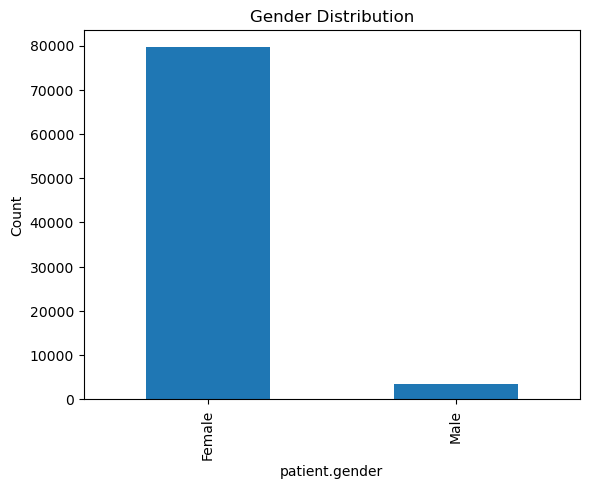

In [9]:
reports_df["patient.gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.show()

#### Age Distribution

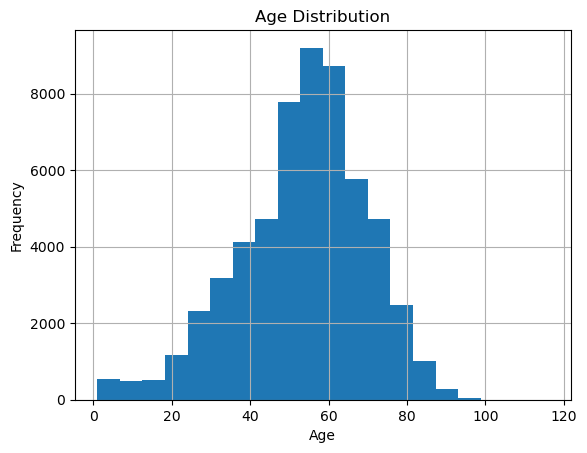

In [10]:
reports_df["patient.age"] = pd.to_numeric(reports_df["patient.age"], errors="coerce")

reports_df["patient.age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### Top 10 Products (From products_df)

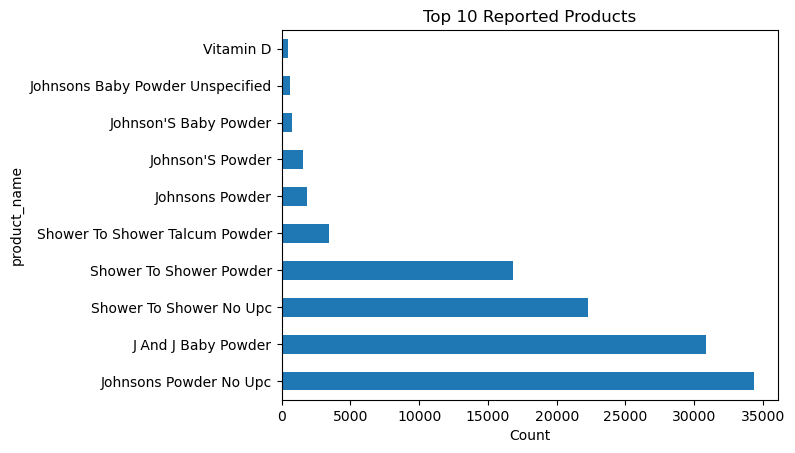

In [11]:
top_products = products_df["product_name"].value_counts().head(10)

top_products.plot(kind="barh")
plt.title("Top 10 Reported Products")
plt.xlabel("Count")
plt.show()

#### Top 10 Reactions (From reactions_df)

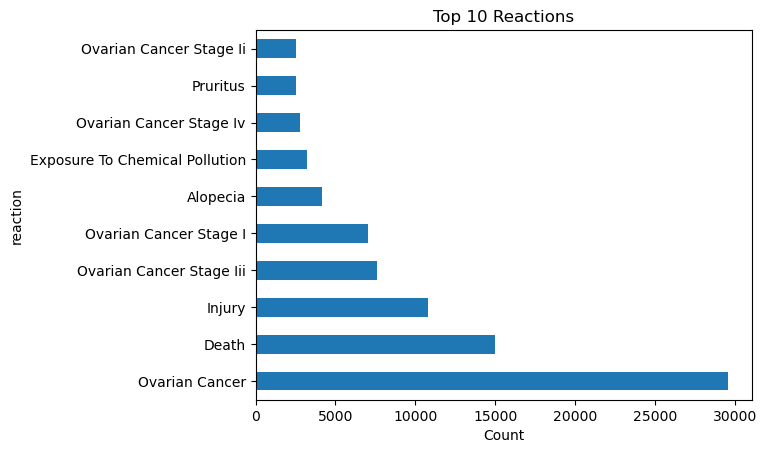

In [12]:
top_reactions = reactions_df["reaction"].value_counts().head(10)

top_reactions.plot(kind="barh")
plt.title("Top 10 Reactions")
plt.xlabel("Count")
plt.show()

#### Outcome Distribution (From outcomes_df)

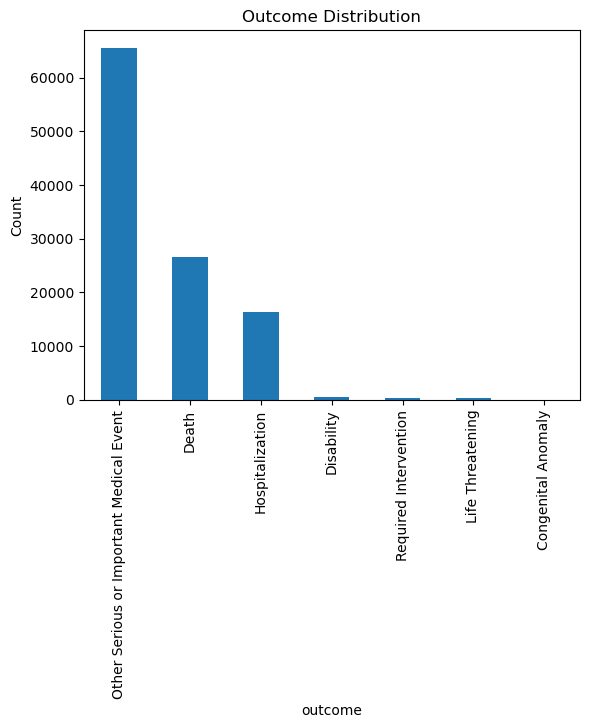

In [13]:
outcomes_df["outcome"].value_counts().plot(kind="bar")
plt.title("Outcome Distribution")
plt.ylabel("Count")
plt.show()

#### Reports Over Time

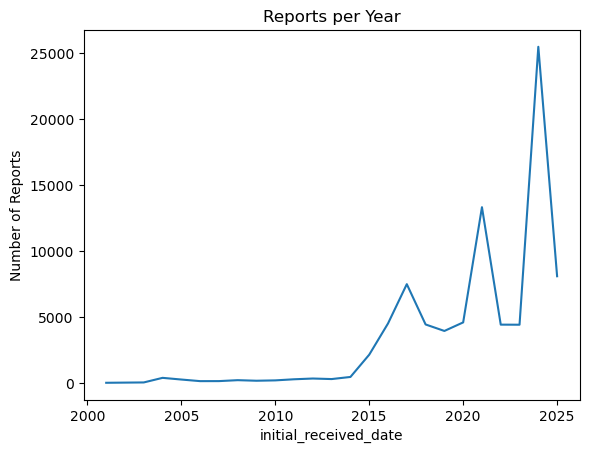

In [14]:
# convert data
reports_df["initial_received_date"] = pd.to_datetime(
    reports_df["initial_received_date"], errors="coerce"
)
reports_df["initial_received_date"].dt.year.value_counts().sort_index().plot()
plt.title("Reports per Year")
plt.ylabel("Number of Reports")
plt.show()

#### Products Associated with Serious Outcomes

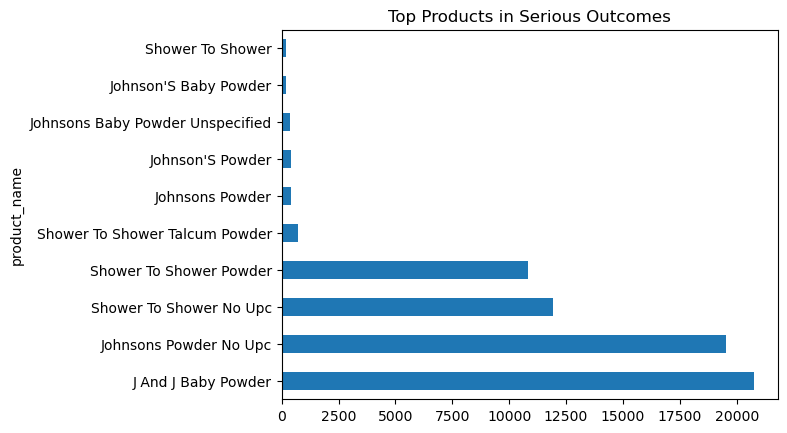

In [15]:
merged = products_df.merge(outcomes_df, on="report_number", how="inner")

serious = merged[
    merged["outcome"].isin(["Death", "Hospitalization"])
]

serious["product_name"].value_counts().head(10).plot(kind="barh")
plt.title("Top Products in Serious Outcomes")
plt.show()

In [16]:
summary = {
    "Total Reports": len(reports_df),
    "Total Products Mentioned": len(products_df),
    "Total Reactions": len(reactions_df),
    "Total Outcomes": len(outcomes_df),
    "Unique Products": products_df["product_name"].nunique(),
    "Unique Reactions": reactions_df["reaction"].nunique()
}

summary

{'Total Reports': 85511,
 'Total Products Mentioned': 148603,
 'Total Reactions': 140893,
 'Total Outcomes': 109824,
 'Unique Products': 17019,
 'Unique Reactions': 2157}

## Basic Exploration (EDA)

#### 1️⃣ MISSING VALUES

In [17]:
#### For reports_df
# Count missing values
missing_reports = reports_df.isnull().sum()

# Percentage missing
missing_reports_percent = (reports_df.isnull().sum() / len(reports_df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_reports,
    "Missing %": missing_reports_percent
}).sort_values("Missing %", ascending=False)

missing_summary.head(20)

,Missing Count,Missing %
legacy_report_id,34064,39.835811
patient.age,28465,33.288115
patient.age_unit,28465,33.288115
event_date,15668,18.322789
patient.gender,2394,2.799640
meddra_version,0,0.000000
report_number,0,0.000000
latest_received_date,0,0.000000
report_type,0,0.000000
initial_received_date,0,0.000000


In [18]:
##### For products_df
products_df.isnull().sum()

report_number    0
product_role     0
product_name     0
dtype: int64

In [19]:
#### For reactions_df
reactions_df.isnull().sum()

report_number    0
reaction         0
dtype: int64

In [20]:
##### for outcomes_df
outcomes_df.isnull().sum()

report_number    0
outcome          0
dtype: int64

#### 2️⃣ DUPLICATES

In [23]:
reports_df["report_number"].duplicated().sum()

0

In [24]:
products_df.duplicated().sum()

5

In [25]:
reactions_df.duplicated().sum()

0

In [26]:
outcomes_df.duplicated().sum()

0

#### 3️⃣ DESCRIPTIVE STATISTICS

In [27]:
### Numerical Columns (Reports)
reports_df["patient.age"] = pd.to_numeric(
    reports_df["patient.age"], errors="coerce"
)

reports_df.describe()

,initial_received_date,patient.age
count,85511,57046.000000
mean,2021-06-11 14:20:05.992211456,53.300638
min,2001-08-09 00:00:00,1.000000
25%,2019-01-10 00:00:00,44.000000
50%,2021-12-21 00:00:00,55.000000
75%,2024-04-10 00:00:00,65.000000
max,2025-08-29 00:00:00,116.000000
std,NaN,16.203023


In [28]:
##### Categorical Summary
reports_df["patient.gender"].value_counts()
reports_df["report_type"].value_counts()

report_type
Pre-MoCRA                   34651
Expedited (15-Day)          33599
Direct                      17255
Non-Expedited (Periodic)        6
Name: count, dtype: int64

#### 4️⃣ OUTLIERS

In [29]:
Q1 = reports_df["patient.age"].quantile(0.25)
Q3 = reports_df["patient.age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = reports_df[
    (reports_df["patient.age"] < lower_bound) |
    (reports_df["patient.age"] > upper_bound)
]

print("Number of age outliers:", len(outliers))

Number of age outliers: 1030


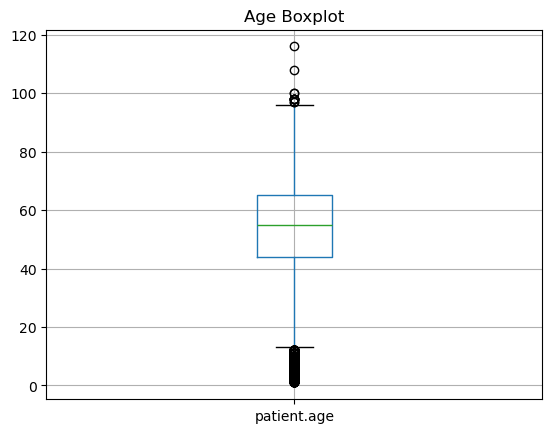

In [30]:
import matplotlib.pyplot as plt

reports_df.boxplot(column="patient.age")
plt.title("Age Boxplot")
plt.show()

## DSO2: Launch a Virtual Training and Interaction Platform

### Data Collection

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, get_dataset_config_names
import warnings
warnings.filterwarnings('ignore')

# Configuration du style des graphiques
plt.style.use('ggplot')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("DATA ACQUISITION & UNDERSTANDING - DSO2".center(80))
print("=" * 80)

                    DATA ACQUISITION & UNDERSTANDING - DSO2                     


In [3]:
# ==========================================
# 2. DATA COLLECTION
# ==========================================

print("\nLoading datasets from Hugging Face...")

wikimedqa = load_dataset("sileod/wikimedqa", "medwiki")
pubmedqa = load_dataset("qiaojin/PubMedQA", "pqa_artificial")

df_wiki = pd.DataFrame(wikimedqa["train"])
df_pubmed = pd.DataFrame(pubmedqa["train"])

print("Datasets loaded successfully!")
print("WikiMedQA:", df_wiki.shape)
print("PubMedQA:", df_pubmed.shape)


Loading datasets from Hugging Face...
Datasets loaded successfully!
WikiMedQA: (67608, 11)
PubMedQA: (211269, 5)


## DSO3

## DSO4

### Data collection

In [26]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from scipy import stats


In [28]:
df_hourly = pd.read_csv('saleshourly.csv')
df_daily = pd.read_csv('salesdaily.csv')
df_weekly = pd.read_csv('salesweekly.csv')
df_monthly = pd.read_csv('salesmonthly.csv')

print("--- Hourly Data ---")
print(df_hourly.head())
print(df_hourly.info())
print("\n--- Daily Data ---")
print(df_daily.head())
print(df_daily.info())
print("\n--- Weekly Data ---")
print(df_weekly.head())
print(df_weekly.info())
print("\n--- Monthly Data ---")
print(df_monthly.head())
print(df_monthly.info())

--- Hourly Data ---
            datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C  R03  R06  Year  \
0   1/2/2014 8:00    0.0   0.67    0.4    2.0   0.0   0.0  0.0  1.0  2014   
1   1/2/2014 9:00    0.0   0.00    1.0    0.0   2.0   0.0  0.0  0.0  2014   
2  1/2/2014 10:00    0.0   0.00    0.0    3.0   2.0   0.0  0.0  0.0  2014   
3  1/2/2014 11:00    0.0   0.00    0.0    2.0   1.0   0.0  0.0  0.0  2014   
4  1/2/2014 12:00    0.0   2.00    0.0    5.0   2.0   0.0  0.0  0.0  2014   

   Month  Hour Weekday Name  
0      1     8     Thursday  
1      1     9     Thursday  
2      1    10     Thursday  
3      1    11     Thursday  
4      1    12     Thursday  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         50532 non-null  object 
 1   M01AB         50532 non-null  float64
 2   M01AE         50532 non-null  float64
 3   N02BA   

In [29]:
df_hourly['date'] = pd.to_datetime(df_hourly['datum'])
df_hourly['year_month'] = df_hourly['date'].dt.to_period('M')

df_daily['date'] = pd.to_datetime(df_daily['datum'])
df_daily['year_month'] = df_daily['date'].dt.to_period('M')

df_weekly['date'] = pd.to_datetime(df_weekly['datum'])
df_weekly['year_month'] = df_weekly['date'].dt.to_period('M')

df_monthly['date'] = pd.to_datetime(df_monthly['datum'])
df_monthly['year_month'] = df_monthly['date'].dt.to_period('M')

print("\n 'year_month' columns created for all DataFrames")


 'year_month' columns created for all DataFrames


In [30]:
df_hourly_monthly = df_hourly.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Hourly data aggregated: {len(df_hourly_monthly)} months")

df_daily_monthly = df_daily.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Daily data aggregated: {len(df_daily_monthly)} months")

df_weekly_monthly = df_weekly.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Weekly data aggregated: {len(df_weekly_monthly)} months")

df_monthly_clean = df_monthly[['year_month', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].copy()
print(f" Monthly data: {len(df_monthly_clean)} months")

 Hourly data aggregated: 70 months
 Daily data aggregated: 70 months
 Weekly data aggregated: 70 months
 Monthly data: 70 months


In [31]:

print("\n--- Merging monthly data ---")

all_months = pd.concat([
    df_hourly_monthly['year_month'],
    df_daily_monthly['year_month'],
    df_weekly_monthly['year_month'],
    df_monthly_clean['year_month']
]).unique()
all_months = pd.Series(sorted(all_months)).reset_index(drop=True)
df_final_monthly = pd.DataFrame({'year_month': all_months})
print(f"✓ Period covered: {len(df_final_monthly)} unique months")

def merge_with_priority(df_base, df_new, priority_name):
    """Merges df_new into df_base with a suffix for traceability"""
    return df_base.merge(
        df_new, 
        on='year_month', 
        how='left', 
        suffixes=('', f'_{priority_name}')
    )

# Priority 1: Monthly data (most reliable source for the month)
df_final_monthly = merge_with_priority(df_final_monthly, df_monthly_clean, 'monthly')

# Priority 2: Aggregated weekly data
df_final_monthly = merge_with_priority(df_final_monthly, df_weekly_monthly, 'weekly')

# Priority 3: Aggregated daily data
df_final_monthly = merge_with_priority(df_final_monthly, df_daily_monthly, 'daily')

# Priority 4: Aggregated hourly data
df_final_monthly = merge_with_priority(df_final_monthly, df_hourly_monthly, 'hourly')


for col in ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']:
    # Create a list of columns in priority order
    priority_cols = [
        f'{col}_monthly',
        f'{col}_weekly',
        f'{col}_daily',
        f'{col}_hourly'
    ]
    
    df_final_monthly[col] = np.nan
    
    for pcol in priority_cols:
        if pcol in df_final_monthly.columns:
            df_final_monthly[col] = df_final_monthly[col].fillna(df_final_monthly[pcol])
            df_final_monthly.drop(columns=[pcol], inplace=True)
    
    df_final_monthly[col] = df_final_monthly[col].round(2)

print(" Merge completed with priority: monthly > weekly > daily > hourly")


--- Merging monthly data ---
✓ Period covered: 70 unique months
 Merge completed with priority: monthly > weekly > daily > hourly


In [32]:
df_final_monthly['year'] = df_final_monthly['year_month'].dt.year
df_final_monthly['month'] = df_final_monthly['year_month'].dt.month
df_final_monthly['quarter'] = df_final_monthly['year_month'].dt.quarter

df_final_monthly['date'] = df_final_monthly['year_month'].dt.to_timestamp()

print(" Temporal columns added")


sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df_final_monthly['total_sales'] = df_final_monthly[sales_columns].sum(axis=1).round(2)

print(" Total sales calculated")



df_final_monthly = df_final_monthly.sort_values('date').reset_index(drop=True)


print("\n--- Final monthly DataFrame overview ---")
print(f"Dimensions: {df_final_monthly.shape[0]} rows, {df_final_monthly.shape[1]} columns")
print(f"Period: {df_final_monthly['date'].min().date()} to {df_final_monthly['date'].max().date()}")
print("\nFirst rows:")
print(df_final_monthly.head(12).to_string())  # Display a full year

print("\nLast rows:")
print(df_final_monthly.tail(12).to_string())

print("\nDescriptive statistics:")
print(df_final_monthly[sales_columns + ['total_sales']].describe().round(2))

 Temporal columns added
 Total sales calculated

--- Final monthly DataFrame overview ---
Dimensions: 70 rows, 14 columns
Period: 2014-01-01 to 2019-10-01

First rows:
   year_month   M01AB   M01AE   N02BA    N02BE    N05B   N05C    R03     R06  year  month  quarter       date  total_sales
0     2014-01  108.00   83.06  136.60   774.65  289.00  21.00  105.0   36.20  2014      1        1 2014-01-01      1553.51
1     2014-02  126.01  118.01  165.50   940.08  370.00  38.00  113.0   41.20  2014      2        1 2014-02-01      1911.80
2     2014-03  159.10  114.68  170.66   929.08  268.00  21.00  124.0   86.40  2014      3        1 2014-03-01      1872.92
3     2014-04  109.43   82.02  114.75   611.40  190.00  16.00   89.0   73.30  2014      4        2 2014-04-01      1285.90
4     2014-05   94.09  108.32  122.40   597.90  230.00  24.00  101.0  105.00  2014      5        2 2014-05-01      1382.71
5     2014-06  122.78  110.77  146.00   656.60  382.00  25.00   75.0  134.40  2014      6     

In [33]:
df_final_monthly.to_excel('hcp_sales_monthly_final.xlsx', index=False)
print("\n File 'hcp_sales_monthly_final.xlsx' created successfully!")

print("\n--- Quick quality check ---")
print(f"Missing values: {df_final_monthly[sales_columns].isnull().sum().sum()}")
print(f"Duplicate months: {df_final_monthly['year_month'].duplicated().sum()}")

# Check month continuity
all_months_expected = pd.period_range(
    start=df_final_monthly['year_month'].min(), 
    end=df_final_monthly['year_month'].max(), 
    freq='M'
)
missing_months = set(all_months_expected) - set(df_final_monthly['year_month'])
if missing_months:
    print(f"⚠️ Missing months: {sorted([str(m) for m in missing_months])}")
else:
    print(" Complete monthly series")

print("\n" + "="*60)
print("ANALYSIS COMPLETED - MONTHLY FILE READY")
print("="*60)


 File 'hcp_sales_monthly_final.xlsx' created successfully!

--- Quick quality check ---
Missing values: 0
Duplicate months: 0
 Complete monthly series

ANALYSIS COMPLETED - MONTHLY FILE READY


### Data augmentation

In [34]:
df_original = pd.read_excel('hcp_sales_monthly_final.xlsx')
print(f"\n Original data: {df_original.shape[0]} months, {df_original.shape[1]} columns")
print(f"Period: {df_original['date'].min()} to {df_original['date'].max()}")

df_original['date'] = pd.to_datetime(df_original['date'])

sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

if 'year_month' in df_original.columns:
    df_original = df_original.drop(columns=['year_month'])

for col in sales_columns:
    if col in df_original.columns:
        df_original[col] = pd.to_numeric(df_original[col], errors='coerce').fillna(0)

df_original['total_sales'] = df_original[sales_columns].sum(axis=1)

print(f" Data prepared: {df_original.shape[0]} rows, {df_original.shape[1]} columns")


 Original data: 70 months, 14 columns
Period: 2014-01-01 00:00:00 to 2019-10-01 00:00:00
 Data prepared: 70 rows, 13 columns


In [35]:
# ======================================================================
# METHOD 1: PRODUCT DECOMPOSITION (create rows by category)
# ======================================================================
print("\n" + "="*60)
print("METHOD 1: PRODUCT CATEGORY DECOMPOSITION")
print("="*60)

product_categories = {
    'Anti-inflammatories': ['M01AB', 'M01AE'],
    'Analgesics': ['N02BA', 'N02BE'],
    'Psychotropics': ['N05B', 'N05C'],
    'Respiratory': ['R03', 'R06']
}

category_rows = []
for idx, row in df_original.iterrows():
    for category, products in product_categories.items():
        category_sales = sum([row[prod] for prod in products])
        new_row = {
            'date': row['date'],
            'year': int(row['year']) if 'year' in row else row['date'].year,
            'month': int(row['month']) if 'month' in row else row['date'].month,
            'quarter': int(row['quarter']) if 'quarter' in row else (row['date'].month-1)//3 + 1,
            'category': category,
            'sales': float(category_sales),
            'product_count': len(products)
        }
        category_rows.append(new_row)

df_by_category = pd.DataFrame(category_rows)
print(f" After category decomposition: {df_by_category.shape[0]} rows")


METHOD 1: PRODUCT CATEGORY DECOMPOSITION
 After category decomposition: 280 rows


In [36]:
# ======================================================================
# METHOD 2: CREATING SYNTHETIC MONTHS THROUGH INTERPOLATION
# ======================================================================
print("\n" + "="*60)
print("METHOD 2: INTERPOLATION TO CREATE ADDITIONAL MONTHS")
print("="*60)

all_months = pd.date_range(start=df_original['date'].min(), 
                           end=df_original['date'].max(), 
                           freq='MS')

df_temp = df_original.set_index('date')
df_interpolated = df_temp.reindex(all_months)

for col in sales_columns + ['total_sales']:
    if col in df_interpolated.columns:
        df_interpolated[col] = df_interpolated[col].interpolate(method='linear').round(2)

df_interpolated['year'] = df_interpolated.index.year
df_interpolated['month'] = df_interpolated.index.month
df_interpolated['quarter'] = df_interpolated.index.quarter

df_interpolated = df_interpolated.reset_index().rename(columns={'index': 'date'})

for col in sales_columns + ['total_sales']:
    if col in df_interpolated.columns:
        df_interpolated[col] = df_interpolated[col].fillna(method='bfill').fillna(method='ffill')

print(f" After interpolation: {df_interpolated.shape[0]} months")
print(f"   (+{df_interpolated.shape[0] - df_original.shape[0]} interpolated months)")


METHOD 2: INTERPOLATION TO CREATE ADDITIONAL MONTHS
 After interpolation: 70 months
   (+0 interpolated months)


In [37]:
# ======================================================================
# METHOD 3: CREATING MONTHLY FEATURES (CYCLICAL FEATURES)
# ======================================================================
print("\n" + "="*60)
print("METHOD 3: CREATING CYCLICAL FEATURES")
print("="*60)

df_features = df_original.copy()

if 'month' not in df_features.columns:
    df_features['month'] = df_features['date'].dt.month
if 'quarter' not in df_features.columns:
    df_features['quarter'] = df_features['date'].dt.quarter
if 'year' not in df_features.columns:
    df_features['year'] = df_features['date'].dt.year

df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12).astype(float)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12).astype(float)

df_features['quarter_sin'] = np.sin(2 * np.pi * df_features['quarter'] / 4).astype(float)
df_features['quarter_cos'] = np.cos(2 * np.pi * df_features['quarter'] / 4).astype(float)

df_features['is_winter'] = df_features['month'].isin([12, 1, 2]).astype(int)
df_features['is_spring'] = df_features['month'].isin([3, 4, 5]).astype(int)
df_features['is_summer'] = df_features['month'].isin([6, 7, 8]).astype(int)
df_features['is_fall'] = df_features['month'].isin([9, 10, 11]).astype(int)

print(f" Features added: {df_features.shape[1] - df_original.shape[1]} new columns")


METHOD 3: CREATING CYCLICAL FEATURES
 Features added: 8 new columns


In [38]:
# ======================================================================
# METHOD 4: BOOTSTRAP DATA GENERATION (WITH NOISE)
# ======================================================================
print("\n" + "="*60)
print("METHOD 4: BOOTSTRAP WITH CONTROLLED NOISE ADDITION")
print("="*60)

np.random.seed(42)  

std_per_product = df_original[sales_columns].std()
mean_per_product = df_original[sales_columns].mean()

n_bootstrap = 20  # Reduced to avoid overload
bootstrap_rows = []

for i in range(n_bootstrap):
    n_samples = max(5, int(0.6 * len(df_original)))
    sample_indices = np.random.choice(df_original.index, size=n_samples, replace=True)
    sample = df_original.loc[sample_indices].copy()
    
    for col in sales_columns:
        noise = np.random.normal(0, std_per_product[col] * 0.05, size=len(sample))
        sample[col] = sample[col] + noise
        sample[col] = sample[col].clip(lower=0)  # No negative sales
    
    sample['total_sales'] = sample[sales_columns].sum(axis=1)
    sample['bootstrap_id'] = i
    sample['source_detail'] = f'bootstrap_{i}'
    
    bootstrap_rows.append(sample)

if bootstrap_rows:
    df_bootstrap = pd.concat(bootstrap_rows, ignore_index=True)
    print(f" After bootstrap: {df_bootstrap.shape[0]} rows")
else:
    df_bootstrap = pd.DataFrame()


METHOD 4: BOOTSTRAP WITH CONTROLLED NOISE ADDITION
 After bootstrap: 840 rows


In [39]:
# ======================================================================
# METHOD 5: CREATING SYNTHETIC MONTHS THROUGH TEMPORAL AUGMENTATION
# ======================================================================
print("\n" + "="*60)
print("METHOD 5: TEMPORAL AUGMENTATION")
print("="*60)

time_shifts = [-2, -1, 1, 2]  # shifts in months
shifted_rows = []

for shift in time_shifts:
    df_shifted = df_original.copy()
    
    new_dates = []
    for date in df_shifted['date']:
        new_date = date + pd.DateOffset(months=shift)
        new_dates.append(new_date)
    
    df_shifted['date'] = new_dates
    df_shifted['shift'] = shift
    
    df_shifted['year'] = df_shifted['date'].dt.year
    df_shifted['month'] = df_shifted['date'].dt.month
    df_shifted['quarter'] = df_shifted['date'].dt.quarter
    
    min_date = df_original['date'].min() - pd.DateOffset(months=6)
    max_date = df_original['date'].max() + pd.DateOffset(months=6)
    
    mask = (df_shifted['date'] >= min_date) & (df_shifted['date'] <= max_date)
    df_shifted = df_shifted[mask]
    
    if len(df_shifted) > 0:
        shifted_rows.append(df_shifted)

if shifted_rows:
    df_shifted_all = pd.concat(shifted_rows, ignore_index=True)
    print(f" After temporal shifts: {df_shifted_all.shape[0]} rows")
else:
    df_shifted_all = pd.DataFrame()


METHOD 5: TEMPORAL AUGMENTATION
 After temporal shifts: 280 rows


In [40]:

print("\n" + "="*60)
print("PREPARING DATASETS FOR CONCATENATION")
print("="*60)

base_columns = ['date', 'year', 'month', 'quarter', 'total_sales'] + sales_columns

def clean_dataframe(df, source_name):
    if df is None or len(df) == 0:
        return None
    
    df_clean = df.copy()
    
    for col in base_columns:
        if col not in df_clean.columns and col != 'source':
            if col in sales_columns:
                df_clean[col] = 0.0
            elif col in ['year', 'month', 'quarter']:
                if 'date' in df_clean.columns:
                    df_clean[col] = df_clean['date'].dt.year if col == 'year' else \
                                   df_clean['date'].dt.month if col == 'month' else \
                                   df_clean['date'].dt.quarter
    
    df_clean['source'] = source_name
    
    available_cols = [col for col in base_columns + ['source'] if col in df_clean.columns]
    
    return df_clean[available_cols]

datasets_to_concat = []

df_orig_clean = clean_dataframe(df_original, 'original')
if df_orig_clean is not None:
    datasets_to_concat.append(df_orig_clean)
    print(f" Original dataset: {len(df_orig_clean)} rows")

df_features_clean = clean_dataframe(df_features, 'with_features')
if df_features_clean is not None:
    datasets_to_concat.append(df_features_clean)
    print(f" Features dataset: {len(df_features_clean)} rows")

df_interp_clean = clean_dataframe(df_interpolated, 'interpolated')
if df_interp_clean is not None and len(df_interp_clean) > len(df_original):
    orig_dates = set(df_original['date'].dt.strftime('%Y-%m-%d'))
    
    new_dates_mask = ~df_interp_clean['date'].dt.strftime('%Y-%m-%d').isin(orig_dates)
    df_interp_new = df_interp_clean[new_dates_mask].copy()
    
    if len(df_interp_new) > 0:
        datasets_to_concat.append(df_interp_new)
        print(f" Interpolated dataset (new months): {len(df_interp_new)} rows")

if not df_bootstrap.empty:
    df_bootstrap_clean = clean_dataframe(df_bootstrap, 'bootstrap')
    if df_bootstrap_clean is not None and len(df_bootstrap_clean) > 0:
        if len(df_bootstrap_clean) > 100:
            df_bootstrap_clean = df_bootstrap_clean.sample(n=100, random_state=42)
        datasets_to_concat.append(df_bootstrap_clean)
        print(f" Bootstrap dataset: {len(df_bootstrap_clean)} rows")

if not df_shifted_all.empty:
    df_shifted_clean = clean_dataframe(df_shifted_all, 'shifted')
    if df_shifted_clean is not None and len(df_shifted_clean) > 0:
        # Limit to 80 rows maximum
        if len(df_shifted_clean) > 80:
            df_shifted_clean = df_shifted_clean.sample(n=80, random_state=42)
        datasets_to_concat.append(df_shifted_clean)
        print(f" Shifted dataset: {len(df_shifted_clean)} rows")

for category, products in product_categories.items():
    cat_data = df_by_category[df_by_category['category'] == category].copy()
    
    if len(cat_data) > 0:
        cat_expanded = []
        for _, row in cat_data.iterrows():
            new_row = {
                'date': row['date'],
                'year': int(row['year']),
                'month': int(row['month']),
                'quarter': int(row['quarter']),
                'total_sales': float(row['sales']),
                'source': f'category_{category}'
            }
            for prod in products:
                new_row[prod] = float(row['sales'] / row['product_count'])
            for prod in sales_columns:
                if prod not in new_row:
                    new_row[prod] = 0.0
            cat_expanded.append(new_row)
        
        if cat_expanded:
            df_cat = pd.DataFrame(cat_expanded)
            datasets_to_concat.append(df_cat)
            print(f" Category {category} dataset: {len(df_cat)} rows")


PREPARING DATASETS FOR CONCATENATION
 Original dataset: 70 rows
 Features dataset: 70 rows
 Bootstrap dataset: 100 rows
 Shifted dataset: 80 rows
 Category Anti-inflammatories dataset: 70 rows
 Category Analgesics dataset: 70 rows
 Category Psychotropics dataset: 70 rows
 Category Respiratory dataset: 70 rows


In [41]:
print("\n" + "="*60)
print("FINAL CONCATENATION")
print("="*60)

if len(datasets_to_concat) == 0:
    print(" No datasets to concatenate!")
    exit()

df_combined = pd.concat(datasets_to_concat, ignore_index=True, sort=False)

for col in sales_columns + ['total_sales']:
    if col in df_combined.columns:
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce').fillna(0).astype(float)

df_combined['date'] = pd.to_datetime(df_combined['date'])

df_combined = df_combined.sort_values('date').reset_index(drop=True)

print(f"\n FINAL RESULT:")
print(f"   - Original dataset: {df_original.shape[0]} rows")
print(f"   - Augmented dataset: {df_combined.shape[0]} rows")
print(f"   - Augmentation: {df_combined.shape[0] / df_original.shape[0]:.1f}x")
print(f"   - Sources: {df_combined['source'].nunique()} different types")

# Save
df_combined.to_excel('hcp_sales_monthly_augmented.xlsx', index=False)
print("\n✅ File 'hcp_sales_monthly_augmented.xlsx' created successfully!")


print("\n" + "="*60)
print("COMPARATIVE STATISTICS")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Number of rows', 'Mean sales', 'Median sales', 'Std deviation', 'Min', 'Max'],
    'Original': [
        df_original.shape[0],
        df_original['total_sales'].mean(),
        df_original['total_sales'].median(),
        df_original['total_sales'].std(),
        df_original['total_sales'].min(),
        df_original['total_sales'].max()
    ],
    'Augmented': [
        df_combined.shape[0],
        df_combined['total_sales'].mean(),
        df_combined['total_sales'].median(),
        df_combined['total_sales'].std(),
        df_combined['total_sales'].min(),
        df_combined['total_sales'].max()
    ]
})

print(comparison.round(2).to_string(index=False))

print("\n Distribution by source:")
source_dist = df_combined['source'].value_counts()
for src, count in source_dist.items():
    print(f"   - {src}: {count} rows ({count/len(df_combined)*100:.1f}%)")

print("\n" + "="*80)
print("DATA AUGMENTATION COMPLETED SUCCESSFULLY!")
print("="*80)


FINAL CONCATENATION

 FINAL RESULT:
   - Original dataset: 70 rows
   - Augmented dataset: 600 rows
   - Augmentation: 8.6x
   - Sources: 8 different types

✅ File 'hcp_sales_monthly_augmented.xlsx' created successfully!

COMPARATIVE STATISTICS
        Metric  Original  Augmented
Number of rows     70.00     600.00
    Mean sales   1822.79    1175.35
  Median sales   1819.92    1305.56
 Std deviation    453.49     789.32
           Min    609.54      55.13
           Max   3271.98    3271.98

 Distribution by source:
   - bootstrap: 100 rows (16.7%)
   - shifted: 80 rows (13.3%)
   - category_Anti-inflammatories: 70 rows (11.7%)
   - original: 70 rows (11.7%)
   - category_Analgesics: 70 rows (11.7%)
   - category_Psychotropics: 70 rows (11.7%)
   - with_features: 70 rows (11.7%)
   - category_Respiratory: 70 rows (11.7%)

DATA AUGMENTATION COMPLETED SUCCESSFULLY!


## Pre-treatment 

## DSO2

In [4]:

# ==========================================
# 4. CHECK DATA QUALITY
# ==========================================

print("\n" + "="*50)
print("DATA QUALITY CHECK")
print("="*50)

# Missing value percentage
def missing_percentage(df):
    return (df.isnull().sum() / len(df)) * 100

print("\nMissing % - WikiMedQA")
print(missing_percentage(df_wiki))

print("\nMissing % - PubMedQA")
print(missing_percentage(df_pubmed))
 


DATA QUALITY CHECK

Missing % - WikiMedQA
text        0.0
option_0    0.0
option_1    0.0
option_2    0.0
option_3    0.0
option_4    0.0
option_5    0.0
option_6    0.0
option_7    0.0
label       0.0
idx         0.0
dtype: float64

Missing % - PubMedQA
pubid             0.0
question          0.0
context           0.0
long_answer       0.0
final_decision    0.0
dtype: float64



Generating EDA Visualizations...


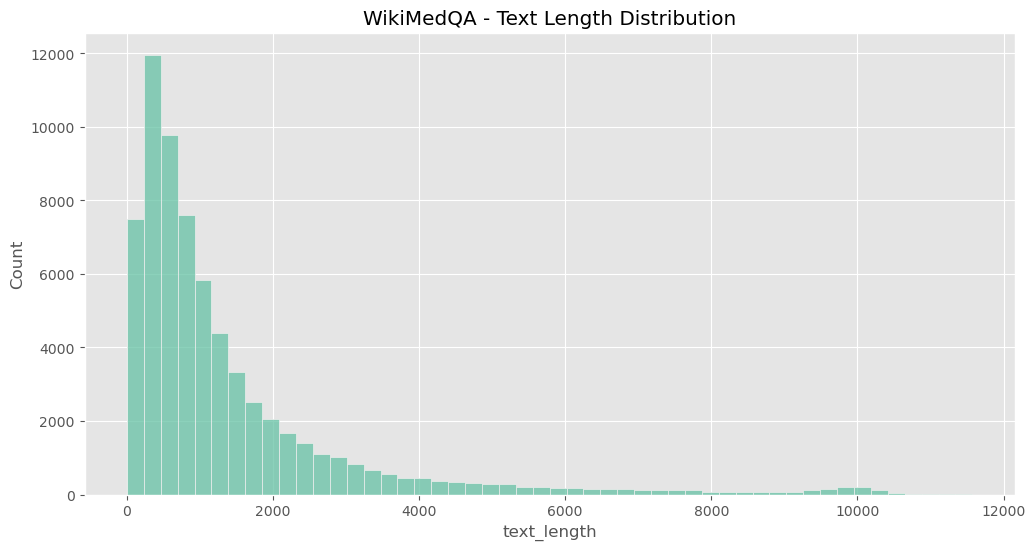

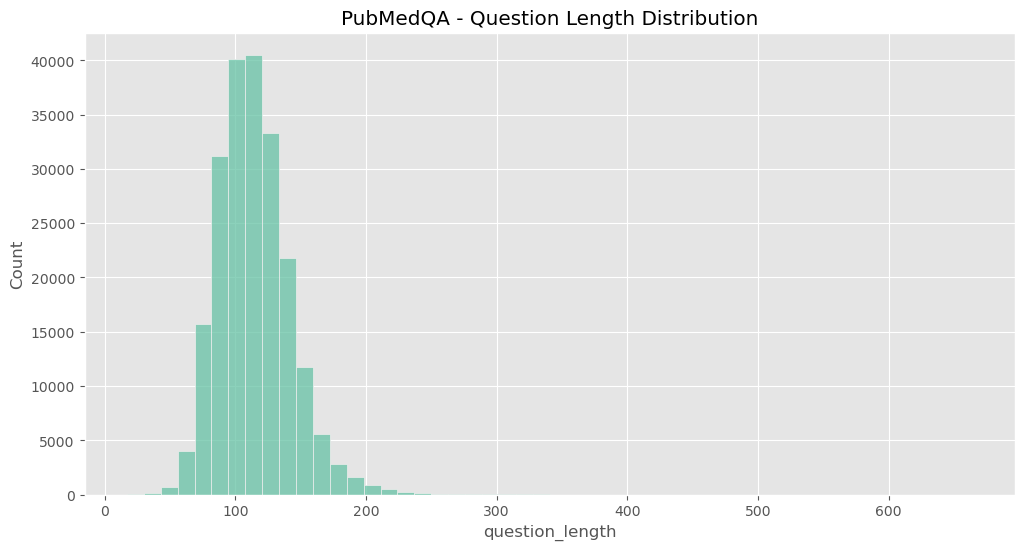

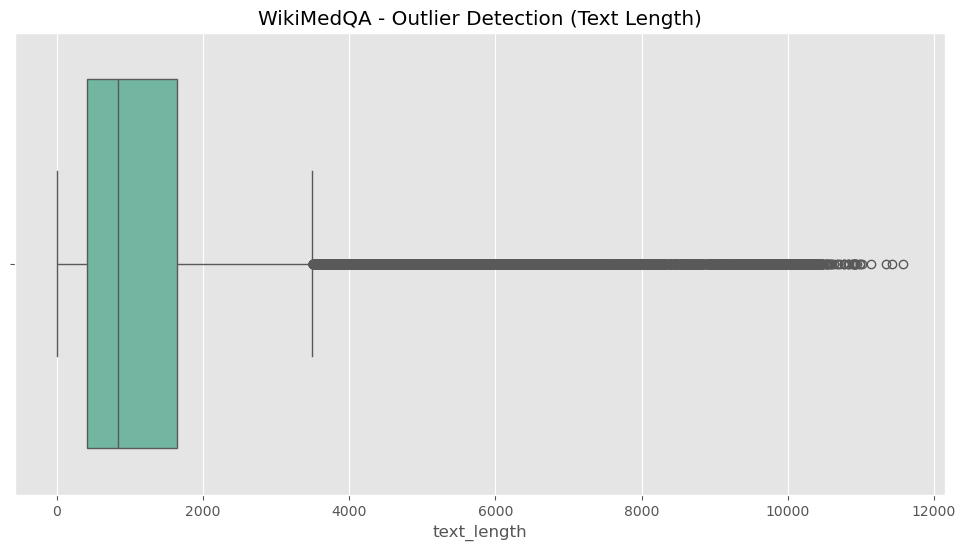

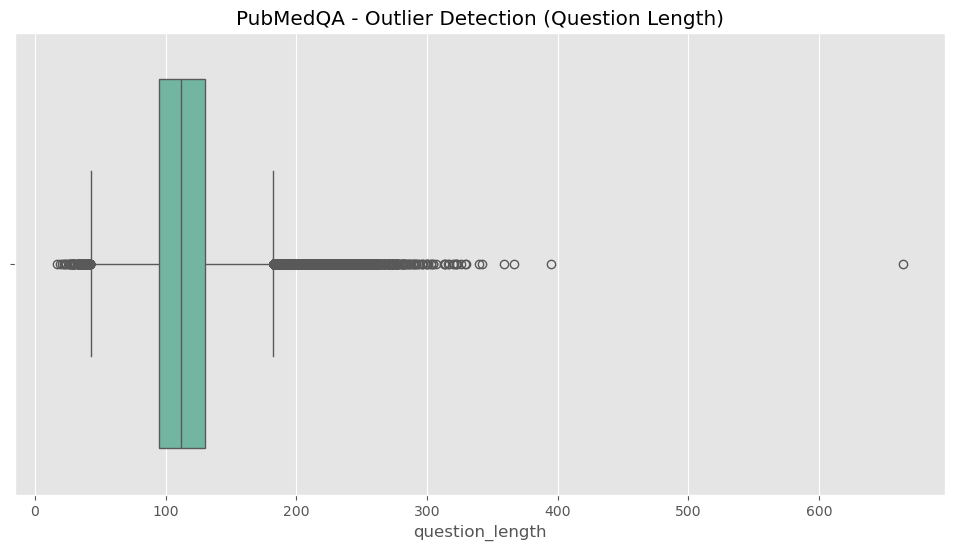

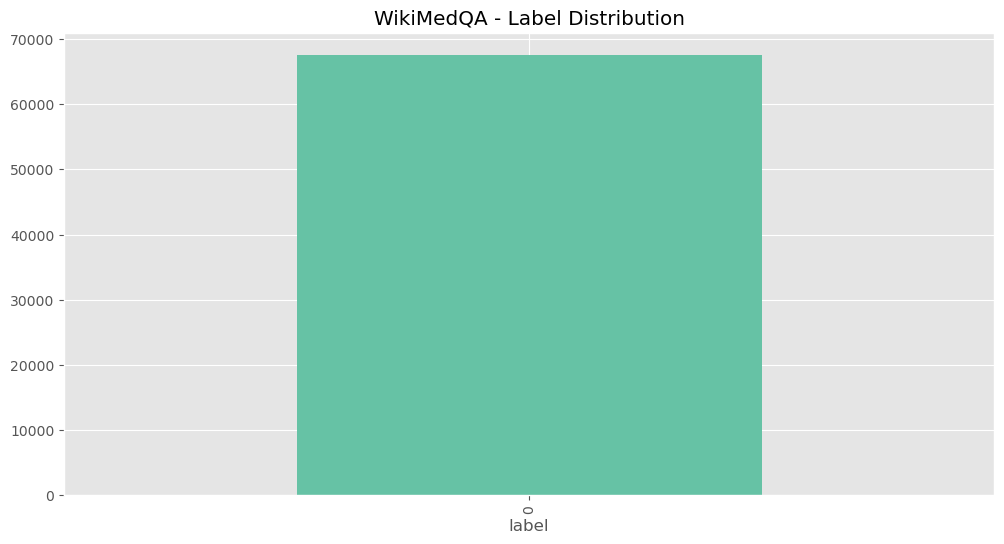

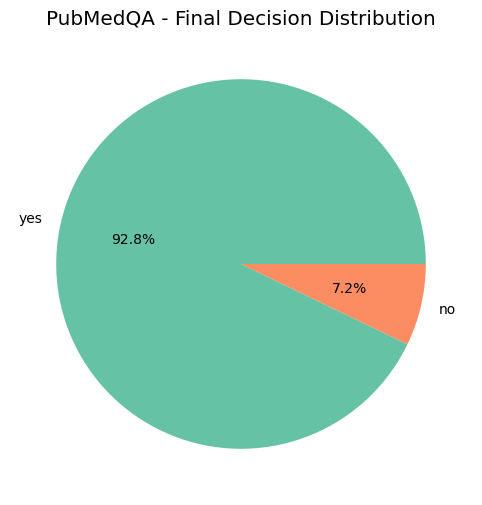

In [5]:

# ==========================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

print("\nGenerating EDA Visualizations...")

# --- Text Length Analysis ---
if "text" in df_wiki.columns:
    df_wiki["text_length"] = df_wiki["text"].astype(str).str.len()

    plt.figure()
    sns.histplot(df_wiki["text_length"], bins=50)
    plt.title("WikiMedQA - Text Length Distribution")
    plt.show()

if "question" in df_pubmed.columns:
    df_pubmed["question_length"] = df_pubmed["question"].astype(str).str.len()

    plt.figure()
    sns.histplot(df_pubmed["question_length"], bins=50)
    plt.title("PubMedQA - Question Length Distribution")
    plt.show()


# --- Outlier Detection using Boxplot ---
if "text_length" in df_wiki.columns:
    plt.figure()
    sns.boxplot(x=df_wiki["text_length"])
    plt.title("WikiMedQA - Outlier Detection (Text Length)")
    plt.show()

if "question_length" in df_pubmed.columns:
    plt.figure()
    sns.boxplot(x=df_pubmed["question_length"])
    plt.title("PubMedQA - Outlier Detection (Question Length)")
    plt.show()


# --- Label Distribution ---
if "label" in df_wiki.columns:
    plt.figure()
    df_wiki["label"].value_counts().plot(kind="bar")
    plt.title("WikiMedQA - Label Distribution")
    plt.show()

if "final_decision" in df_pubmed.columns:
    plt.figure()
    df_pubmed["final_decision"].value_counts().plot(kind="pie", autopct="%1.1f%%")
    plt.title("PubMedQA - Final Decision Distribution")
    plt.ylabel("")
    plt.show()

## DSO4

In [42]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("EXPLORATORY ANALYSIS OF AUGMENTED MONTHLY DATA - PREPROCESSING")
print("="*80)


print("\n1. LOADING AUGMENTED MONTHLY DATA")
print("-" * 40)

try:
    df = pd.read_excel('hcp_sales_monthly_augmented.xlsx')
    print(f" AUGMENTED monthly file loaded successfully")
except FileNotFoundError:
    try:
        df = pd.read_excel('hcp_sales_monthly_final.xlsx')
        print(f"  Augmented file not found, using original file")
    except FileNotFoundError:
        print(" No file found. Please run the merge code first.")
        exit()

print(f"   - Number of rows (months): {df.shape[0]:,}")
print(f"   - Number of columns: {df.shape[1]}")
print(f"   - Period covered: from {df['date'].min()} to {df['date'].max()}")

df['date'] = pd.to_datetime(df['date'])

sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
sales_columns = [col for col in sales_columns if col in df.columns]

if 'total_sales' not in df.columns and len(sales_columns) > 0:
    df['total_sales'] = df[sales_columns].sum(axis=1)

if 'year' not in df.columns:
    df['year'] = df['date'].dt.year
if 'month' not in df.columns:
    df['month'] = df['date'].dt.month
if 'quarter' not in df.columns:
    df['quarter'] = df['date'].dt.quarter

print(f"\n Data prepared: {df.shape[0]} rows, {df.shape[1]} columns")
if 'source' in df.columns:
    print(f"   - Data sources: {df['source'].nunique()} types")
    print(df['source'].value_counts().to_string())

EXPLORATORY ANALYSIS OF AUGMENTED MONTHLY DATA - PREPROCESSING

1. LOADING AUGMENTED MONTHLY DATA
----------------------------------------
 AUGMENTED monthly file loaded successfully
   - Number of rows (months): 600
   - Number of columns: 14
   - Period covered: from 2014-01-01 00:00:00 to 2019-11-01 00:00:00

 Data prepared: 600 rows, 14 columns
   - Data sources: 8 types
source
bootstrap                       100
shifted                          80
category_Anti-inflammatories     70
original                         70
category_Analgesics              70
category_Psychotropics           70
with_features                    70
category_Respiratory             70


In [43]:

print("\n2. OVERVIEW OF MONTHLY DATA")
print("-" * 40)

print("\n First 12 months (one full year):")
print(df.head(12).to_string())

print("\n Last 12 months:")
print(df.tail(12).to_string())

print("\n General information about the monthly DataFrame:")
print(df.info())

print("\n Descriptive statistics of monthly sales:")
print(df.describe(include='all').round(2))


2. OVERVIEW OF MONTHLY DATA
----------------------------------------

 First 12 months (one full year):
         date  year  month  quarter  total_sales       M01AB       M01AE       N02BA       N02BE        N05B        N05C         R03        R06                        source
0  2014-01-01  2014      1        1  1553.510000  108.000000   83.060000  136.600000  774.650000  289.000000   21.000000  105.000000  36.200000                      original
1  2014-01-01  2014      1        1  1552.647050  109.084105   80.903970  136.115431  786.097176  284.250547   20.975984   96.181774  39.038063                     bootstrap
2  2014-01-01  2014      1        1  1569.749596  106.340458   81.615359  136.355939  791.194297  290.899572   21.126479  102.703119  39.514374                     bootstrap
3  2014-01-01  2014      1        1  1561.560052  109.908119   82.105813  137.086582  775.229224  293.401229   20.662636  104.457731  38.708719                     bootstrap
4  2014-01-01  2014      

In [44]:
print("\n3. MISSING VALUES ANALYSIS")
print("-" * 40)

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing values': missing_values.values,
    'Percentage (%)': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing values'] > 0].sort_values('Missing values', ascending=False)

print(f"\n Total number of cells: {df.size:,}")
print(f" Total number of missing values: {df.isnull().sum().sum():,}")
print(f" Overall percentage of missing values: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

if len(missing_df) > 0:
    print("\n Details by column:")
    print(missing_df.to_string(index=False))
    
    # Visualization of missing values
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Bar chart
    axes[0].barh(missing_df['Column'], missing_df['Missing values'])
    axes[0].set_xlabel('Number of missing values')
    axes[0].set_title('Missing values by column')
    
    # Heatmap of missing values
    sns.heatmap(df[missing_df['Column']].isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
    axes[1].set_title('Missing values pattern')
    axes[1].set_xlabel('Columns')
    
    plt.tight_layout()
    plt.show()
else:
    print(" No missing values detected in the monthly data!")


3. MISSING VALUES ANALYSIS
----------------------------------------

 Total number of cells: 8,400
 Total number of missing values: 0
 Overall percentage of missing values: 0.00%
 No missing values detected in the monthly data!


In [45]:
print("\n4. DUPLICATES ANALYSIS")
print("-" * 40)

duplicates_exact = df.duplicated().sum()
print(f" Exact duplicate rows: {duplicates_exact} ({duplicates_exact/len(df)*100:.2f}%)")

if 'date' in df.columns:
    # Convert to string to avoid timezone issues
    date_strings = df['date'].dt.strftime('%Y-%m-%d')
    duplicates_date = date_strings.duplicated().sum()
    print(f" Duplicate dates: {duplicates_date} ({duplicates_date/len(df)*100:.2f}%)")
    
    if duplicates_date > 0:
        print("\n   Examples of duplicate dates (with sources):")
        dup_dates = date_strings[date_strings.duplicated(keep=False)]
        dup_sample = df[date_strings.isin(dup_dates)].sort_values('date').head(10)
        if 'source' in dup_sample.columns:
            print(dup_sample[['date', 'source', 'total_sales']].to_string())
        else:
            print(dup_sample[['date', 'total_sales']].to_string())


4. DUPLICATES ANALYSIS
----------------------------------------
 Exact duplicate rows: 0 (0.00%)
 Duplicate dates: 529 (88.17%)

   Examples of duplicate dates (with sources):
         date                        source  total_sales
0  2014-01-01                      original  1553.510000
1  2014-01-01                     bootstrap  1552.647050
2  2014-01-01                     bootstrap  1569.749596
3  2014-01-01                     bootstrap  1561.560052
4  2014-01-01  category_Anti-inflammatories   191.060000
5  2014-01-01           category_Analgesics   911.250000
6  2014-01-01        category_Psychotropics   310.000000
7  2014-01-01                 with_features  1553.510000
8  2014-01-01          category_Respiratory   141.200000
16 2014-02-01                     bootstrap  1911.283778



5. OUTLIERS ANALYSIS - MONTHLY DATA
----------------------------------------
 Numeric columns analyzed: total_sales, M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, R06

 Outlier statistics by column:
     Column   Min         Max        Mean      Median    Std Dev  Outliers (IQR)  % Outliers (IQR)  Outliers (Z-score)  % Outliers (Z-score)
total_sales 55.13 3271.980000 1175.345386 1305.560000 789.317277               0              0.00                   0                  0.00
      M01AB  0.00  226.796947   95.272017  123.770389  74.613567               0              0.00                   0                  0.00
      M01AE  0.00  197.465000   77.761636  103.229770  60.631192               0              0.00                   0                  0.00
      N02BA  0.00 1044.610000  121.609036   99.123482 163.204357              61             10.17                  15                  2.50
      N02BE  0.00 1877.820000  534.076514  565.669910 474.786246               0              0.

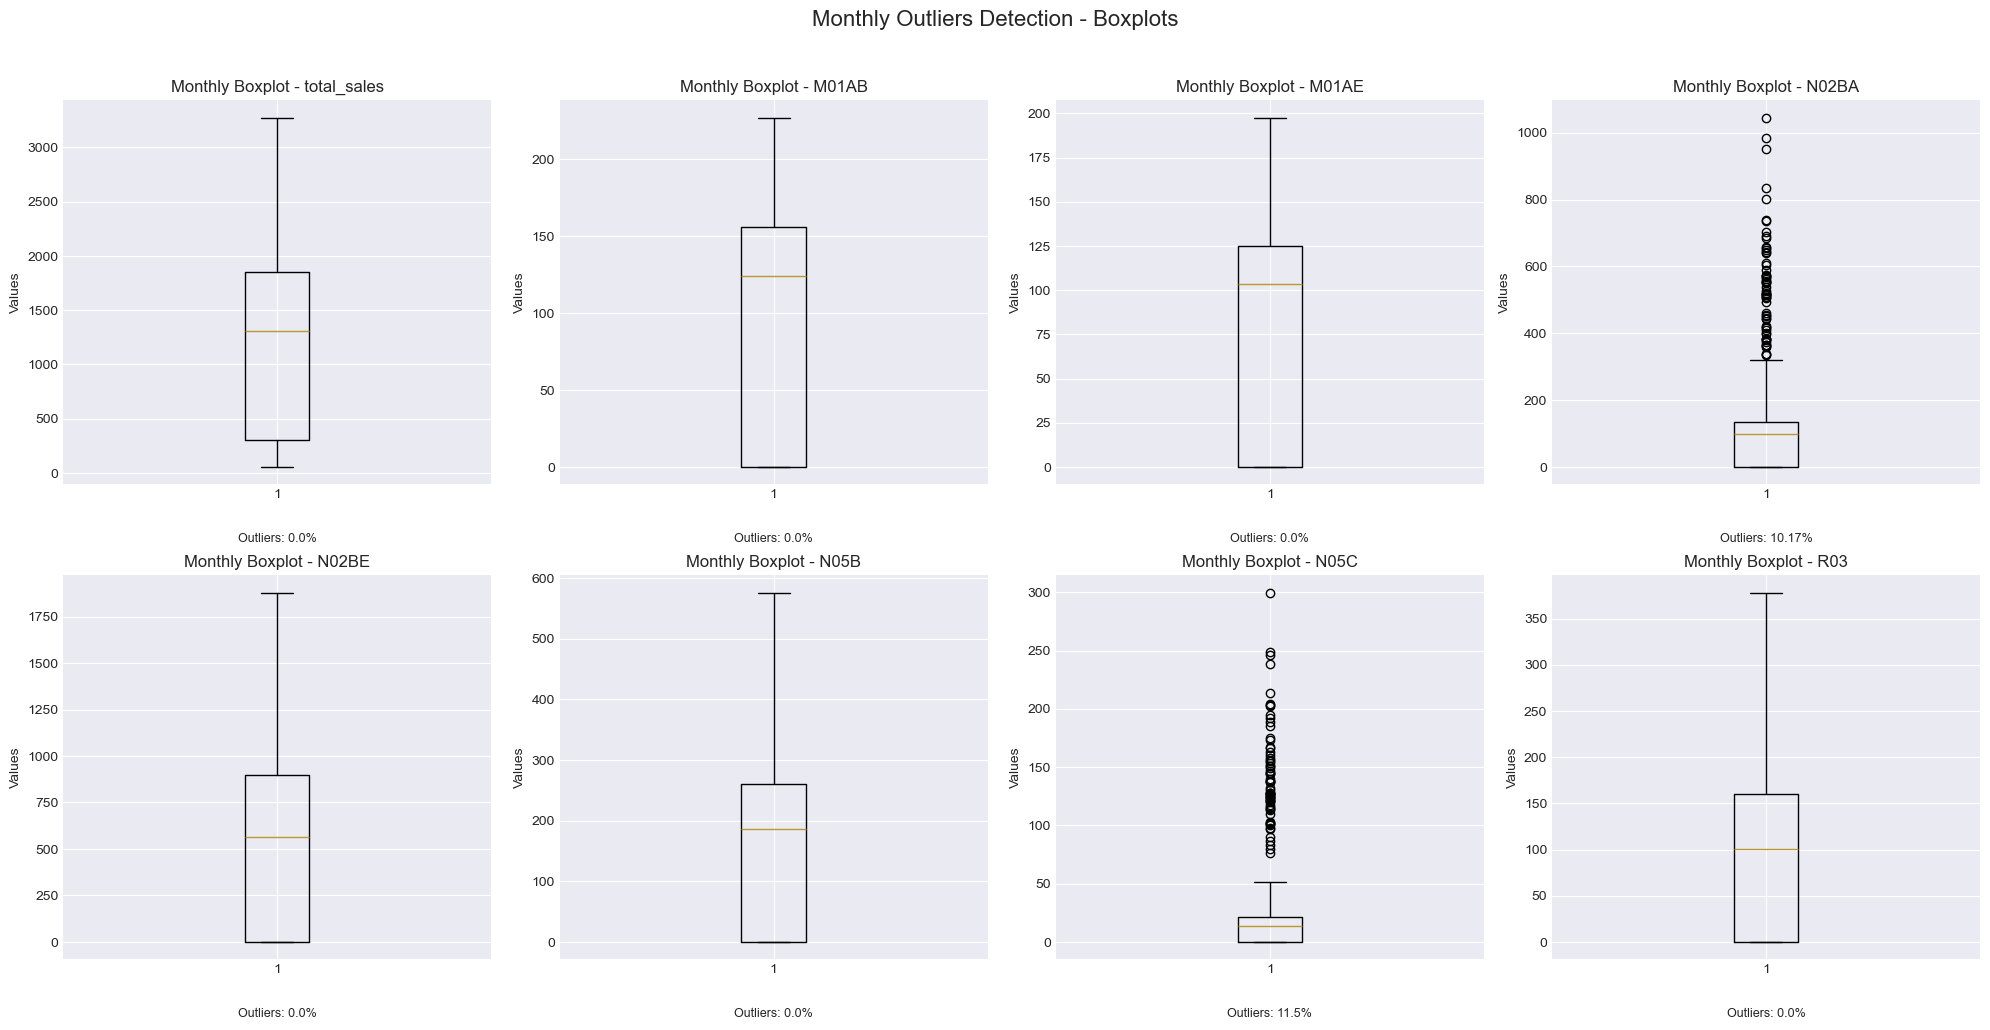

In [46]:
print("\n5. OUTLIERS ANALYSIS - MONTHLY DATA")
print("-" * 40)

exclude_cols = ['date', 'year', 'month', 'quarter', 'source', 'bootstrap_id', 'shift', 'source_detail', 'unique_id']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in exclude_cols and col in sales_columns + ['total_sales']]

print(f" Numeric columns analyzed: {', '.join(numeric_cols)}")

outlier_stats = []

for col in numeric_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()
        pct_outliers_iqr = (outliers_iqr / len(df)) * 100
        
        col_clean = df[col].dropna()
        if len(col_clean) > 1:
            z_scores = np.abs(stats.zscore(col_clean))
            outliers_zscore = (z_scores > 3).sum()
            pct_outliers_zscore = (outliers_zscore / len(df)) * 100
        else:
            outliers_zscore = 0
            pct_outliers_zscore = 0
        
        outlier_stats.append({
            'Column': col,
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Mean': df[col].mean(),
            'Median': df[col].median(),
            'Std Dev': df[col].std(),
            'Outliers (IQR)': outliers_iqr,
            '% Outliers (IQR)': round(pct_outliers_iqr, 2),
            'Outliers (Z-score)': outliers_zscore,
            '% Outliers (Z-score)': round(pct_outliers_zscore, 2)
        })

if outlier_stats:
    outlier_df = pd.DataFrame(outlier_stats)
    print("\n Outlier statistics by column:")
    print(outlier_df.to_string(index=False))

    n_cols = min(len(numeric_cols), 8)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:8]):
        if i < len(axes):
            axes[i].boxplot(df[col].dropna())
            axes[i].set_title(f'Monthly Boxplot - {col}')
            axes[i].set_ylabel('Values')
            
            stats_text = f"Outliers: {outlier_df[outlier_df['Column']==col]['% Outliers (IQR)'].values[0]}%"
            axes[i].text(0.5, -0.15, stats_text, transform=axes[i].transAxes, ha='center', fontsize=9)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Monthly Outliers Detection - Boxplots', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


6. MONTHLY DISTRIBUTION ANALYSIS
----------------------------------------


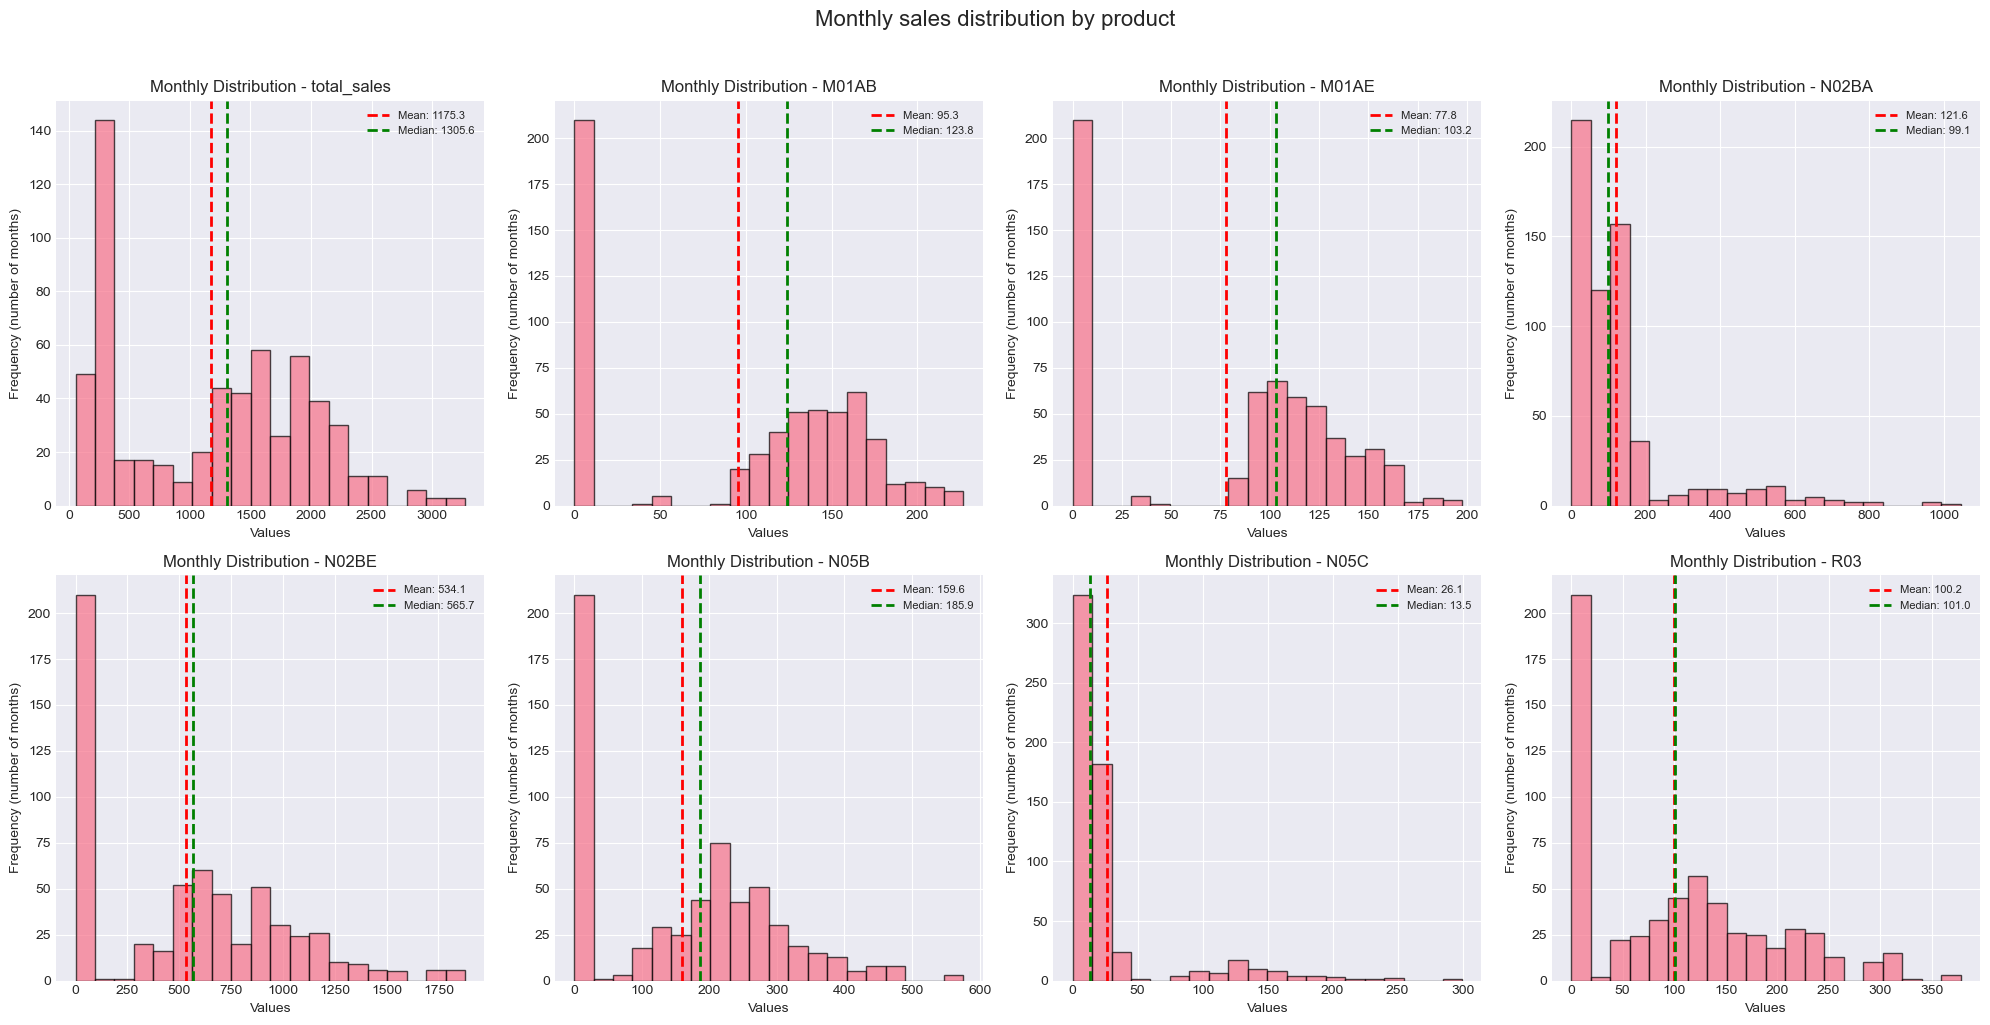

In [48]:
print("\n6. MONTHLY DISTRIBUTION ANALYSIS")
print("-" * 40)

if numeric_cols:
    n_cols = min(len(numeric_cols), 8)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:8]):
        if i < len(axes):
            axes[i].hist(df[col].dropna(), bins=20, edgecolor='black', alpha=0.7)
            axes[i].set_title(f'Monthly Distribution - {col}')
            axes[i].set_xlabel('Values')
            axes[i].set_ylabel('Frequency (number of months)')
            
            # Add lines for mean and median
            mean_val = df[col].mean()
            median_val = df[col].median()
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
            axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
            axes[i].legend(fontsize=8)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Monthly sales distribution by product', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


7. MONTHLY CORRELATION ANALYSIS
----------------------------------------


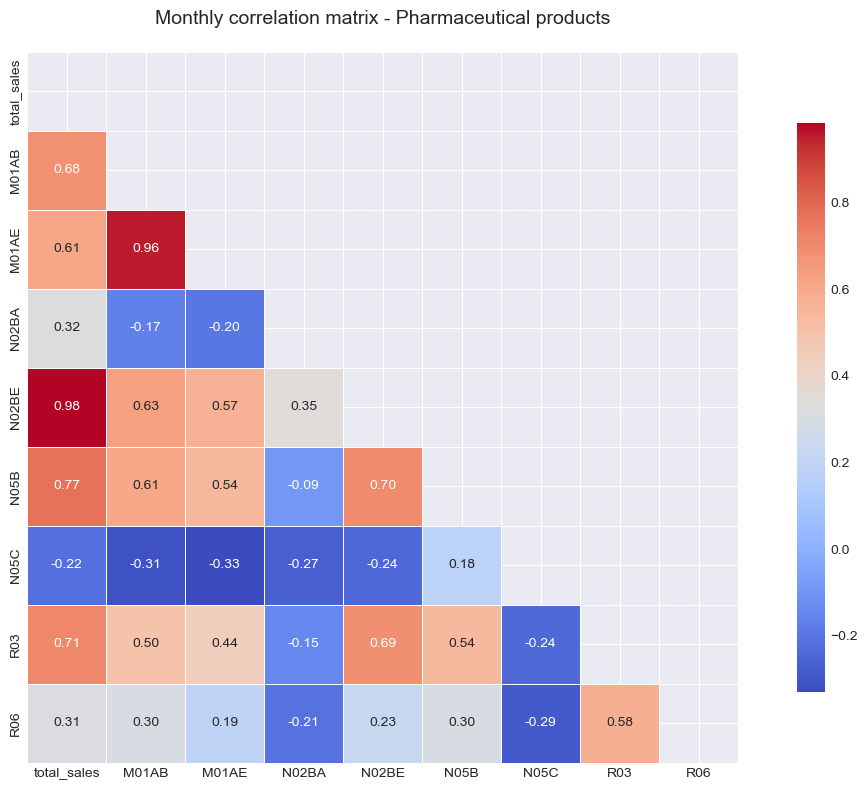


 Strongest monthly correlations (> 0.8 or < -0.8):
  Product 1 Product 2  Correlation
total_sales     N02BE        0.984
      M01AB     M01AE        0.956


In [51]:
print("\n7. MONTHLY CORRELATION ANALYSIS")
print("-" * 40)

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title('Monthly correlation matrix - Pharmaceutical products', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    print("\n Strongest monthly correlations (> 0.8 or < -0.8):")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                corr_pairs.append({
                    'Product 1': corr_matrix.columns[i],
                    'Product 2': corr_matrix.columns[j],
                    'Correlation': round(corr_value, 3)
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
        print(corr_df.to_string(index=False))
    else:
        print("   No very strong correlations detected at monthly level.")


8. MONTHLY TIME SERIES ANALYSIS
----------------------------------------


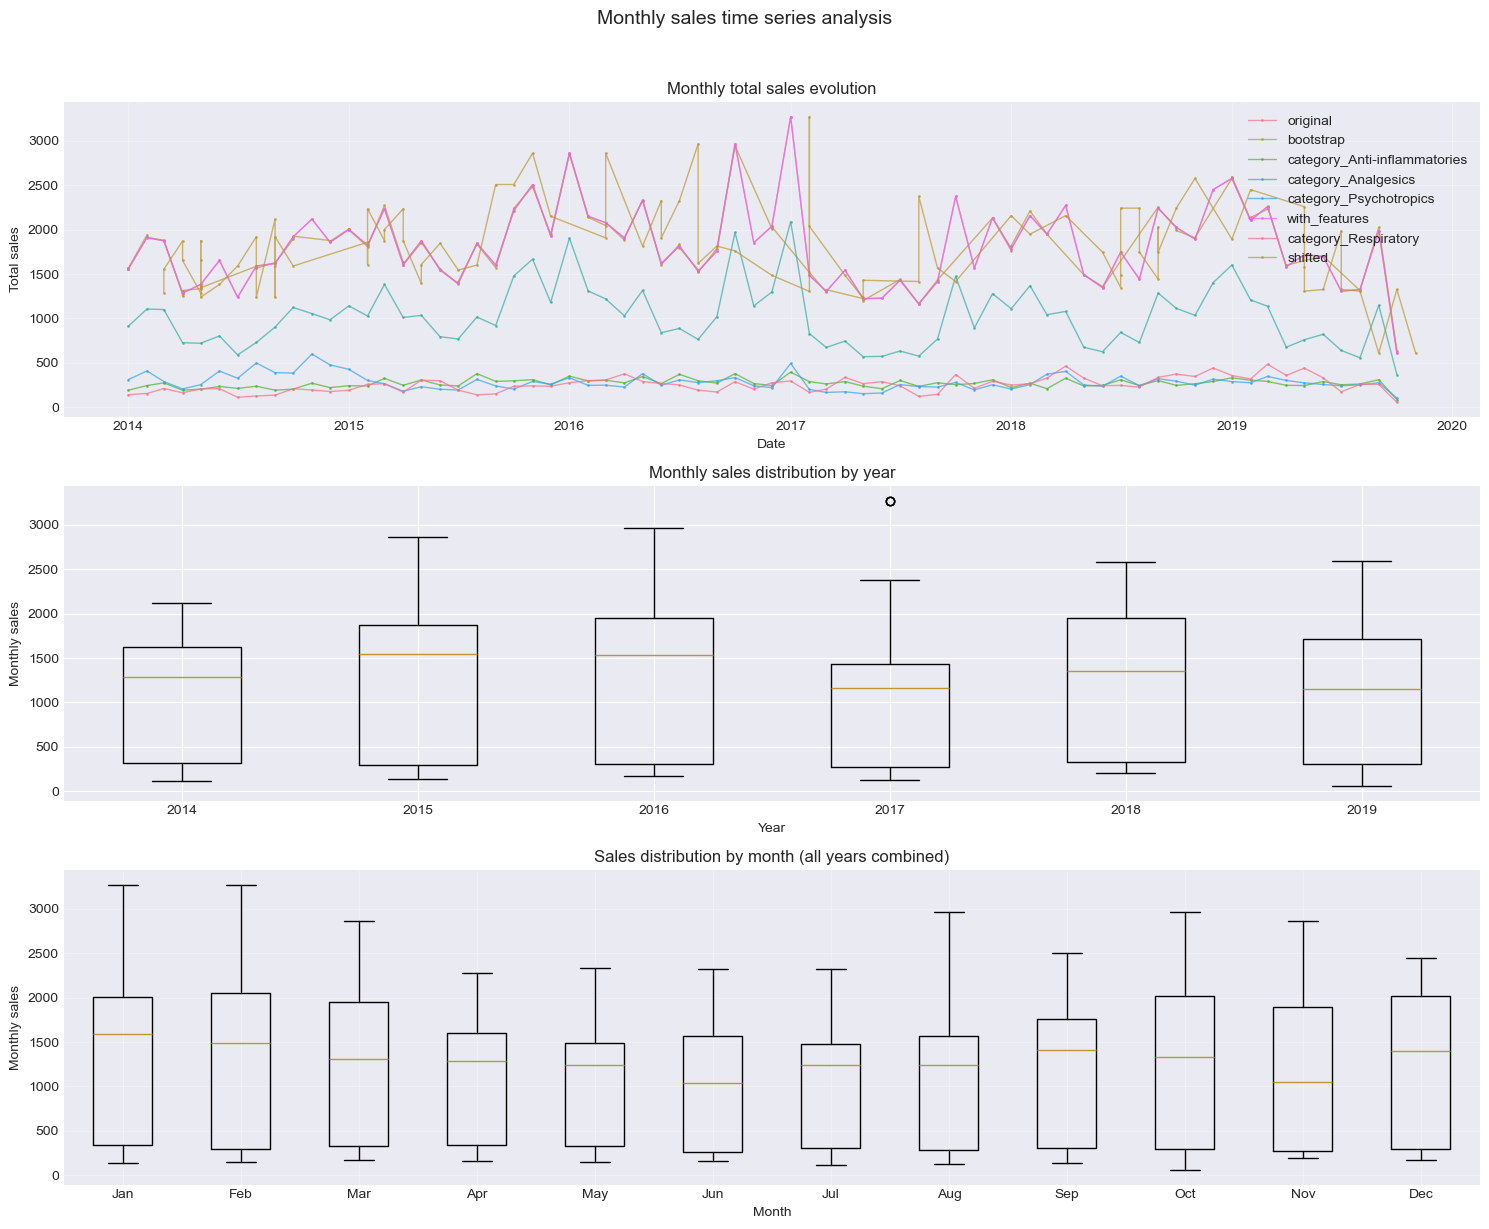

In [52]:
print("\n8. MONTHLY TIME SERIES ANALYSIS")
print("-" * 40)

if 'date' in df.columns and 'total_sales' in df.columns:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    if 'source' in df.columns:
        for source in df['source'].unique():
            source_data = df[df['source'] == source]
            axes[0].plot(source_data['date'], source_data['total_sales'], 
                        marker='.', linestyle='-', linewidth=1, markersize=2, 
                        label=source, alpha=0.7)
        axes[0].legend()
    else:
        axes[0].plot(df['date'], df['total_sales'], marker='o', linestyle='-', markersize=4)
    
    axes[0].set_title('Monthly total sales evolution', fontsize=12)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Total sales')
    axes[0].grid(True, alpha=0.3)
    
    if 'year' in df.columns:
        # Group by year for boxplot
        years = sorted(df['year'].unique())
        data_by_year = [df[df['year'] == year]['total_sales'].values for year in years]
        axes[1].boxplot(data_by_year, labels=years)
        axes[1].set_title('Monthly sales distribution by year')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Monthly sales')
    
    if 'month' in df.columns:
        monthly_data = [df[df['month'] == m]['total_sales'].values for m in range(1, 13)]
        axes[2].boxplot(monthly_data, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        axes[2].set_title('Sales distribution by month (all years combined)')
        axes[2].set_xlabel('Month')
        axes[2].set_ylabel('Monthly sales')
        axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Monthly sales time series analysis', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


9. ANALYSIS BY DATA SOURCE
----------------------------------------
                              total_sales_count  total_sales_mean  total_sales_std  total_sales_min  total_sales_max
source                                                                                                              
bootstrap                                   100           1783.00           393.04           637.01          2944.89
category_Analgesics                          70           1016.82           345.07           367.30          2089.22
category_Anti-inflammatories                 70            268.65            50.98            85.11           394.93
category_Psychotropics                       70            284.22            88.36           102.00           599.00
category_Respiratory                         70            253.10            87.71            55.13           484.00
original                                     70           1822.79           453.49           609.54          327

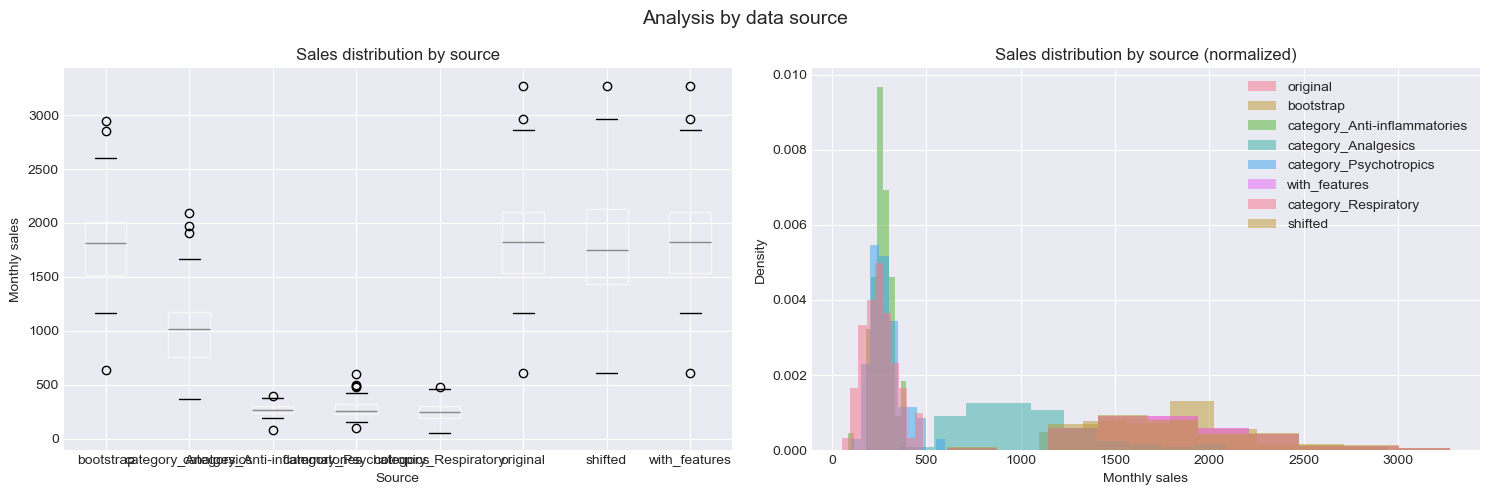

In [53]:
print("\n9. ANALYSIS BY DATA SOURCE")
print("-" * 40)

if 'source' in df.columns:
    source_stats = df.groupby('source').agg({
        'total_sales': ['count', 'mean', 'std', 'min', 'max']
    }).round(2)
    source_stats.columns = ['_'.join(col).strip() for col in source_stats.columns.values]
    print(source_stats.to_string())
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    df.boxplot(column='total_sales', by='source', ax=axes[0])
    axes[0].set_title('Sales distribution by source')
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Monthly sales')
    
    for source in df['source'].unique():
        source_data = df[df['source'] == source]['total_sales']
        axes[1].hist(source_data, bins=10, alpha=0.5, label=source, density=True)
    axes[1].set_title('Sales distribution by source (normalized)')
    axes[1].set_xlabel('Monthly sales')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    
    plt.suptitle('Analysis by data source', fontsize=14)
    plt.tight_layout()
    plt.show()


10. SEASONALITY ANALYSIS
----------------------------------------


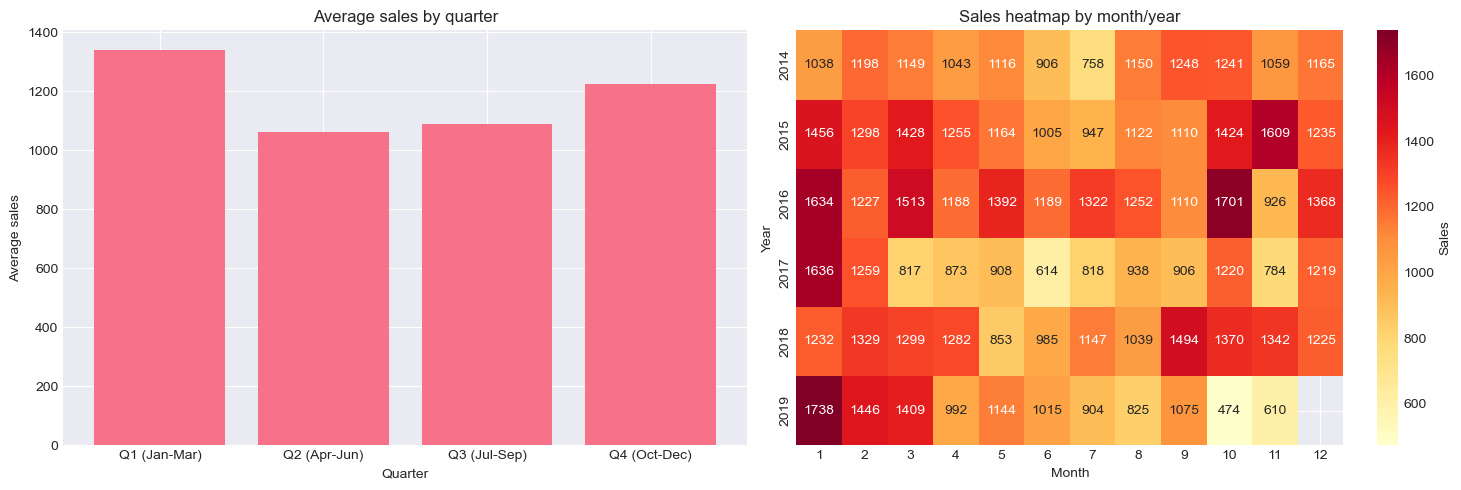

In [54]:
print("\n10. SEASONALITY ANALYSIS")
print("-" * 40)

if 'quarter' in df.columns and 'total_sales' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    quarterly_sales = df.groupby('quarter')['total_sales'].mean()
    quarters = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
    axes[0].bar(quarters, quarterly_sales.values)
    axes[0].set_title('Average sales by quarter')
    axes[0].set_xlabel('Quarter')
    axes[0].set_ylabel('Average sales')
    
    if 'year' in df.columns and 'month' in df.columns:
        pivot_table = df.pivot_table(values='total_sales', index='year', columns='month', aggfunc='mean')
        sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Sales'})
        axes[1].set_title('Sales heatmap by month/year')
        axes[1].set_xlabel('Month')
        axes[1].set_ylabel('Year')
    
    plt.tight_layout()
    plt.show()

In [55]:
print("\n11. MONTHLY DATA QUALITY SUMMARY")
print("-" * 40)

print("""
 POINTS TO CHECK:
""")

if missing_values.sum() > 0:
    print(f"     {missing_values.sum():,} missing values detected")
    print(f"       → Columns affected: {', '.join(missing_df['Column'].tolist())}")
else:
    print("    No missing values in monthly data")

if duplicates_exact > 0:
    print(f"     {duplicates_exact} duplicate rows")
else:
    print("    No duplicate rows")

if 'outlier_df' in locals() and len(outlier_df) > 0:
    cols_with_high_outliers = outlier_df[outlier_df['% Outliers (IQR)'] > 5]['Column'].tolist()
    if cols_with_high_outliers:
        print(f"     Products with >5% monthly outliers: {', '.join(cols_with_high_outliers)}")
    else:
        print("   No major monthly outlier issues")

if 'date' in df.columns:
    date_min = df['date'].min()
    date_max = df['date'].max()
    
    expected_months = pd.date_range(start=date_min, end=date_max, freq='MS')
    actual_dates = pd.to_datetime(df['date'].dt.strftime('%Y-%m-01'))
    missing_months = set(expected_months) - set(actual_dates)
    
    if missing_months:
        print(f"     {len(missing_months)} missing months in the time series")
        print(f"       → Example: {sorted(list(missing_months))[:5]}")
    else:
        print("    Complete and continuous monthly series")

print(f"\n Key monthly sales statistics:")
print(f"   - Average monthly sales: {df['total_sales'].mean():,.2f}")
print(f"   - Median monthly sales: {df['total_sales'].median():,.2f}")
print(f"   - Standard deviation: {df['total_sales'].std():,.2f}")
print(f"   - Coefficient of variation: {(df['total_sales'].std() / df['total_sales'].mean() * 100):.1f}%")
print(f"   - Month with max sales: {df.loc[df['total_sales'].idxmax(), 'date'].strftime('%Y-%m')} ({df['total_sales'].max():,.2f})")
print(f"   - Month with min sales: {df.loc[df['total_sales'].idxmin(), 'date'].strftime('%Y-%m')} ({df['total_sales'].min():,.2f})")

print("\n" + "="*80)
print("MONTHLY ANALYSIS COMPLETED")
print("="*80)


11. MONTHLY DATA QUALITY SUMMARY
----------------------------------------

 POINTS TO CHECK:

    No missing values in monthly data
    No duplicate rows
     Products with >5% monthly outliers: N02BA, N05C
    Complete and continuous monthly series

 Key monthly sales statistics:
   - Average monthly sales: 1,175.35
   - Median monthly sales: 1,305.56
   - Standard deviation: 789.32
   - Coefficient of variation: 67.2%
   - Month with max sales: 2017-01 (3,271.98)
   - Month with min sales: 2019-10 (55.13)

MONTHLY ANALYSIS COMPLETED


# Modeling

## DSO1

## DSO2

## DSO3

In [3]:
"""
DSO3: Compliant Indication Rewriter + Presentation Generator
Version for French Products - On-Demand with Excel Summary
"""

import json
import re
import os
import pandas as pd
from datetime import datetime
from typing import Dict, Optional
from groq import Groq

# ============================================
# CONFIGURATION
# ============================================

class DSO3Config:
    """Configuration for DSO3 Engine"""
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
    MODEL = "llama-3.3-70b-versatile"  # Best for French/English
    TEMPERATURE = 0.1
    MAX_TOKENS = 2048

# ============================================
# EXCEL SUMMARY MANAGER
# ============================================

class ExcelSummaryManager:
    """Manages the summary Excel file with all generated products"""
    
    def __init__(self, excel_path: str = "produits.xlsx"):
        self.excel_path = excel_path
        self.load_or_create()
    
    def load_or_create(self):
        """Load existing Excel or create new one with headers"""
        if os.path.exists(self.excel_path):
            self.df = pd.read_excel(self.excel_path)
            print(f"📊 Excel existant chargé: {len(self.df)} produits déjà générés")
        else:
            # Create new DataFrame with correct columns
            self.df = pd.DataFrame(columns=[
                'Produit',
                'Gamme',
                'Indication_originale',
                'Indication_conforme',
                'Mention_legale_complete',
                'Fichier_PowerPoint',
                'Rapport_fichier',
                'Risques_detectes',
                'Date_generation'
            ])
            print(f"📊 Nouveau fichier Excel créé: {self.excel_path}")
    
    def product_exists(self, product_name: str) -> bool:
        """Check if product already exists in summary"""
        return product_name in self.df['Produit'].values
    
    def add_or_update(self, product_data: Dict):
        """Add new product or update existing one"""
        product_name = product_data['produit']
        
        # Prepare row data
        new_row = {
            'Produit': product_name,
            'Gamme': product_data.get('gamme', ''),
            'Indication_originale': product_data.get('indication', ''),
            'Indication_conforme': product_data.get('compliant_indication', ''),
            'Mention_legale_complete': product_data.get('full_statement', ''),
            'Fichier_PowerPoint': product_data.get('pptx_path', ''),
            'Rapport_fichier': product_data.get('report_path', ''),
            'Risques_detectes': json.dumps(product_data.get('risk_detection', {}), ensure_ascii=False),
            'Date_generation': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        if self.product_exists(product_name):
            # Update existing row
            idx = self.df[self.df['Produit'] == product_name].index[0]
            for key, value in new_row.items():
                self.df.at[idx, key] = value
            print(f"🔄 Produit mis à jour: {product_name}")
        else:
            # Add new row
            self.df = pd.concat([self.df, pd.DataFrame([new_row])], ignore_index=True)
            print(f"✅ Nouveau produit ajouté: {product_name}")
        
        # Save to Excel
        self.df.to_excel(self.excel_path, index=False)
        print(f"💾 Excel sauvegardé: {self.excel_path}")
    
    def get_all_products(self) -> pd.DataFrame:
        """Return all products in summary"""
        return self.df

# ============================================
# THE COMPLIANCE PROMPT
# ============================================

def get_compliance_prompt(product_data: Dict) -> str:
    """Build the RAG prompt with French product data"""
    
    return f"""Vous êtes un expert en conformité réglementaire pour les compléments alimentaires et les produits cosmétiques (directives FDA/EMA et réglementation française).

Voici les données du produit:

NOM DU PRODUIT: {product_data.get('produit', 'Inconnu')}
GAMME: {product_data.get('gamme', 'Non spécifié')}
INDICATION ORIGINALE: {product_data.get('indication', '')}
COMPOSITION: {product_data.get('composition', 'Non spécifiée')}
POSOLOGIE: {product_data.get('posologie', 'Suivre les instructions sur l\'emballage')}

---

TÂCHE 1: DÉTECTER LES PHRASES RISQUÉES
Analysez l'INDICATION ORIGINALE et identifiez:
- Verbes interdits (traite, guérit, prévient, élimine, soigne, combat, détruit)
- Allégations de maladie (acné, eczéma, infection, inflammation, douleur, mycose, constipation, anémie, stress, anxiété, migraine, insomnie)
- Superlatifs/absolus (meilleur, parfait, 100%, garanti, tous, jamais)
- Absence de qualificatifs (devrait avoir "peut aider", "contribue à", "soutient", "maintient")

TÂCHE 2: RÉÉCRIRE EN INDICATION CONFORME
Règles:
- Remplacer les allégations de maladie par des descriptions de fonction corporelle
- Ajouter des qualificatifs: "peut aider", "contribue à", "soutient", "favorise", "maintient"
- Supprimer toutes les allégations absolues
- Pour les compléments alimentaires: aucune mention de maladie
- Pour les cosmétiques: aucune allégation de traitement de maladie

TÂCHE 3: AJOUTER LES MENTIONS LÉGALES OBLIGATOIRES

Pour les COMPLÉMENTS ALIMENTAIRES (produits à avaler):
"⚠️ Ce produit ne peut pas diagnostiquer, traiter, guérir ou prévenir une quelconque maladie. Consultez votre médecin avant utilisation si vous êtes enceinte, allaitez, prenez des médicaments ou avez un problème médical. Ne pas dépasser la dose recommandée."

Pour les PRODUITS COSMÉTIQUES (application sur la peau):
"⚠️ Usage externe uniquement. En cas d'irritation, arrêtez l'utilisation. Évitez le contact avec les yeux. Ce produit n'est pas destiné à traiter des maladies de la peau."

Pour les PRODUITS ANTI-MOUSTIQUES/INSECTES:
"⚠️ Usage externe uniquement. Ne pas appliquer sur les muqueuses ou les plaies. Tenir hors de portée des enfants."

TÂCHE 4: CRÉER UNE PRÉSENTATION DE 7 DIAPOSITIVES
Générez ces diapositives exactement en FRANÇAIS:

1. TITRE: [Nom du produit] — [Catégorie de bénéfice]
2. INTRODUCTION: À qui s'adresse ce produit
3. BÉNÉFICE PRINCIPAL: L'indication conforme
4. COMMENT ÇA MARCHE: Basé sur la composition
5. MODE D'EMPLOI: La posologie
6. SÉCURITÉ: Les mentions légales
7. CONCLUSION: Avertissement légal complet

---

RETOURNEZ UNIQUEMENT DU JSON VALIDE avec cette structure:

{{
  "product_name": "string",
  "risk_detection": {{
    "forbidden_verbs": [],
    "disease_claims": [],
    "superlatives": [],
    "missing_qualifiers": false
  }},
  "compliant_indication": "string",
  "full_compliant_statement": "string",
  "presentation": {{
    "slide1_title": "string",
    "slide2_introduction": "string",
    "slide3_key_benefit": "string",
    "slide4_how_it_works": "string",
    "slide5_usage": "string",
    "slide6_safety": "string",
    "slide7_closing": "string"
  }}
}}"""

# ============================================
# DSO3 ENGINE CLASS
# ============================================

class DSO3Engine:
    """Main engine for compliance rewriting and presentation generation"""
    
    def __init__(self, api_key: str = None):
        self.client = Groq(api_key=api_key or DSO3Config.GROQ_API_KEY)
        self.model = DSO3Config.MODEL
        self.temperature = DSO3Config.TEMPERATURE
        self.max_tokens = DSO3Config.MAX_TOKENS
        self.summary_manager = ExcelSummaryManager()
    
    def process_product(self, product_data: Dict) -> Dict:
        """Process a single product through the entire DSO3 pipeline"""
        
        if not product_data.get('indication'):
            return {
                "error": "Aucune indication fournie",
                "product_name": product_data.get('produit', 'Inconnu')
            }
        
        prompt = get_compliance_prompt(product_data)
        
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {
                        "role": "system", 
                        "content": "Vous êtes un expert en conformité réglementaire. Retournez uniquement du JSON valide."
                    },
                    {
                        "role": "user", 
                        "content": prompt
                    }
                ],
                temperature=self.temperature,
                max_tokens=self.max_tokens,
                response_format={"type": "json_object"}
            )
            
            result = json.loads(response.choices[0].message.content)
            result["processed_at"] = datetime.now().isoformat()
            result["model_used"] = self.model
            
            return result
            
        except Exception as e:
            return {
                "error": str(e),
                "product_name": product_data.get('produit', 'Inconnu'),
                "processed_at": datetime.now().isoformat()
            }
    
    def generate_pptx(self, product_data: Dict, result: Dict, output_folder: str = "presentations") -> Optional[str]:
        """Generate PowerPoint file"""
        try:
            from pptx import Presentation
            import re
            
            os.makedirs(output_folder, exist_ok=True)
            
            prs = Presentation()
            title_slide_layout = prs.slide_layouts[0]
            content_slide_layout = prs.slide_layouts[1]
            
            presentation_data = result.get('presentation', {})
            product_name = product_data.get('produit', 'Inconnu')
            
            # Slide 1
            slide = prs.slides.add_slide(title_slide_layout)
            slide.shapes.title.text = presentation_data.get('slide1_title', product_name)
            slide.placeholders[1].text = "Présentation du produit conforme"
            
            # Slide 2
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Introduction"
            slide.placeholders[1].text = presentation_data.get('slide2_introduction', '')
            
            # Slide 3
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Bénéfice Principal"
            slide.placeholders[1].text = presentation_data.get('slide3_key_benefit', '')
            
            # Slide 4
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Comment ça marche"
            slide.placeholders[1].text = presentation_data.get('slide4_how_it_works', '')
            
            # Slide 5
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Mode d'emploi"
            slide.placeholders[1].text = presentation_data.get('slide5_usage', '')
            
            # Slide 6
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Informations de sécurité"
            slide.placeholders[1].text = presentation_data.get('slide6_safety', '')
            
            # Slide 7
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Mentions légales importantes"
            slide.placeholders[1].text = presentation_data.get('slide7_closing', '')
            
            safe_name = re.sub(r'[\\/*?:"<>|]', "", product_name)
            filename = f"{output_folder}/{safe_name}_presentation.pptx"
            prs.save(filename)
            
            return filename
            
        except ImportError:
            print("⚠️ python-pptx non installé. pip install python-pptx")
            return None
        except Exception as e:
            print(f"❌ Erreur PowerPoint: {e}")
            return None
    
    def generate_text_report(self, product_data: Dict, result: Dict, output_folder: str = "rapports") -> str:
        """Generate text report and save to file"""
        
        os.makedirs(output_folder, exist_ok=True)
        
        product_name = product_data.get('produit', 'Inconnu')
        risk = result.get('risk_detection', {})
        
        report = f"""
{'='*60}
RAPPORT DE CONFORMITÉ: {product_name}
{'='*60}
Généré le: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

🔍 DÉTECTION DES RISQUES
{'-'*40}
Indication originale: {product_data.get('indication', '')}

Verbes interdits trouvés: {', '.join(risk.get('forbidden_verbs', ['Aucun']))}
Allégations maladie trouvées: {', '.join(risk.get('disease_claims', ['Aucune']))}
Superlatifs trouvés: {', '.join(risk.get('superlatives', ['Aucun']))}
Qualificatifs manquants: {'Oui' if risk.get('missing_qualifiers') else 'Non'}

✅ INDICATION CONFORME
{'-'*40}
{result.get('compliant_indication', 'Non disponible')}

⚠️ MENTION LÉGALE COMPLÈTE
{'-'*40}
{result.get('full_compliant_statement', 'Non disponible')}

📊 APERÇU DE LA PRÉSENTATION
{'-'*40}
1. TITRE: {result.get('presentation', {}).get('slide1_title', 'N/A')}
2. INTRODUCTION: {result.get('presentation', {}).get('slide2_introduction', 'N/A')[:100]}...
3. BÉNÉFICE: {result.get('presentation', {}).get('slide3_key_benefit', 'N/A')}
4. FONCTIONNEMENT: {result.get('presentation', {}).get('slide4_how_it_works', 'N/A')[:100]}...
5. MODE D'EMPLOI: {result.get('presentation', {}).get('slide5_usage', 'N/A')}
6. SÉCURITÉ: {result.get('presentation', {}).get('slide6_safety', 'N/A')[:100]}...
7. MENTIONS LÉGALES: {result.get('presentation', {}).get('slide7_closing', 'N/A')[:100]}...

{'='*60}
"""
        report_file = f"{output_folder}/{product_name}_rapport.txt"
        with open(report_file, 'w', encoding='utf-8') as f:
            f.write(report)
        
        return report_file
    
    def generate_for_product(self, product_data: Dict, output_folder: str = "presentations") -> Dict:
        """
        Generate presentation for ONE product and update Excel summary
        This is the main function to call for on-demand generation
        """
        
        print(f"\n{'='*50}")
        print(f"🔄 Génération pour: {product_data.get('produit', 'Inconnu')}")
        print(f"{'='*50}")
        
        # Process through DSO3
        result = self.process_product(product_data)
        
        if result.get('error'):
            return {
                "success": False,
                "error": result['error'],
                "product_name": product_data.get('produit', 'Inconnu')
            }
        
        # Generate PowerPoint
        pptx_path = self.generate_pptx(product_data, result, output_folder)
        
        # Generate text report
        report_path = self.generate_text_report(product_data, result)
        
        # Prepare data for Excel
        excel_data = {
            'produit': product_data.get('produit', 'Inconnu'),
            'gamme': product_data.get('gamme', ''),
            'indication': product_data.get('indication', ''),
            'compliant_indication': result.get('compliant_indication', ''),
            'full_statement': result.get('full_compliant_statement', ''),
            'pptx_path': pptx_path,
            'report_path': report_path,
            'risk_detection': result.get('risk_detection', {})
        }
        
        # Update Excel summary
        self.summary_manager.add_or_update(excel_data)
        
        return {
            "success": True,
            "product_name": product_data.get('produit', 'Inconnu'),
            "compliant_indication": result.get('compliant_indication', ''),
            "full_compliant_statement": result.get('full_compliant_statement', ''),
            "risk_detection": result.get('risk_detection', {}),
            "presentation_slides": result.get('presentation', {}),
            "pptx_path": pptx_path,
            "report_path": report_path,
            "processed_at": result.get('processed_at', '')
        }

# ============================================
# SIMPLE FUNCTION FOR ALIA TO CALL
# ============================================

def generate_presentation_for_product(
    product_name: str,
    indication: str,
    gamme: str = "",
    composition: str = "",
    posologie: str = "",
    output_folder: str = "presentations"
) -> Dict:
    """
    SIMPLE FUNCTION: Call this to generate presentation for ONE product
    
    Example usage:
    
    result = generate_presentation_for_product(
        product_name="DERMACNÉ GÉLULE",
        indication="Purifier la peau et réduire l'acné",
        gamme="COSMOPHARMA",
        composition="Bardane, Zinc",
        posologie="1 à 2 gélules par jour"
    )
    
    if result['success']:
        print(f"✅ Présentation générée: {result['pptx_path']}")
        print(f"📝 Indication conforme: {result['compliant_indication']}")
    """
    
    engine = DSO3Engine()
    
    product_data = {
        "produit": product_name,
        "gamme": gamme or "Non spécifié",
        "indication": indication,
        "composition": composition or "Non spécifiée",
        "posologie": posologie or "Suivre les instructions sur l'emballage"
    }
    
    return engine.generate_for_product(product_data, output_folder)


def show_all_generated_products() -> pd.DataFrame:
    """
    Show all products that have been generated
    Returns the summary Excel as a DataFrame
    """
    manager = ExcelSummaryManager()
    return manager.get_all_products()


# ============================================
# INTERACTIVE COMMAND LINE TOOL
# ============================================

def interactive_mode():
    """Run in interactive mode - user types product name"""
    
    print("""
    ╔══════════════════════════════════════════════════════════╗
    ║     GÉNÉRATEUR DE PRÉSENTATIONS CONFORMES                ║
    ║     Mode interactif - Générer un produit à la fois       ║
    ╚══════════════════════════════════════════════════════════╝
    """)
    
    while True:
        print("\n" + "-" * 40)
        print("Que voulez-vous faire?")
        print("1. Générer une présentation pour un produit")
        print("2. Voir tous les produits déjà générés")
        print("3. Quitter")
        
        choice = input("\nVotre choix (1/2/3): ")
        
        if choice == "1":
            print("\n--- Entrez les informations du produit ---")
            product_name = input("Nom du produit: ")
            indication = input("Indication originale: ")
            gamme = input("Gamme (optionnel): ")
            composition = input("Composition (optionnel): ")
            posologie = input("Posologie (optionnel): ")
            
            print("\n🔄 Génération en cours...")
            
            result = generate_presentation_for_product(
                product_name=product_name,
                indication=indication,
                gamme=gamme,
                composition=composition,
                posologie=posologie
            )
            
            if result['success']:
                print(f"\n✅ SUCCÈS!")
                print(f"📝 Indication conforme: {result['compliant_indication']}")
                print(f"📊 PowerPoint: {result['pptx_path']}")
                print(f"📄 Rapport: {result['report_path']}")
            else:
                print(f"\n❌ ERREUR: {result['error']}")
        
        elif choice == "2":
            df = show_all_generated_products()
            print("\n--- PRODUITS GÉNÉRÉS ---")
            if len(df) > 0:
                print(df[['Produit', 'Indication_conforme', 'Date_generation']].to_string())
            else:
                print("Aucun produit généré pour le moment.")
        
        elif choice == "3":
            print("Au revoir!")
            break
        
        else:
            print("Choix invalide")

def get_product_from_excel(product_name, input_file="extracted_products.xlsx"):

    df = pd.read_excel(input_file)

    product = df[df["Produit"].str.lower() == product_name.lower()]

    if product.empty:
        print("❌ Produit non trouvé dans Excel")
        return None

    row = product.iloc[0]

    product_data = {
        "produit": row.get("Produit"),
        "gamme": row.get("Gamme", ""),
        "indication": row.get("Indication", ""),
        "composition": row.get("Composition", ""),
        "posologie": row.get("Posologie", "")
    }

    return product_data
    
def generate_from_excel(product_name):

    product_data = get_product_from_excel(product_name)

    if product_data is None:
        return

    engine = DSO3Engine()

    result = engine.generate_for_product(product_data)

    return result
# ============================================
# TEST / DEMO
# ============================================

if __name__ == "__main__":    # Example: Generate for ONE product from your dataset
    result = generate_from_excel("Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets")
    
    if result['success']:
        print("\n" + "="*50)
        print("✅ RÉSULTAT:")
        print(f"Produit: {result['product_name']}")
        print(f"Indication conforme: {result['compliant_indication']}")
        print(f"PowerPoint: {result['pptx_path']}")
        print(f"Rapport: {result['report_path']}")
        print("="*50)
        
        # Show all generated products so far
        print("\n📊 Tous les produits générés:")
        df = show_all_generated_products()
        print(df[['Produit', 'Date_generation']].to_string())
    else:
        print(f"❌ Erreur: {result['error']}")

GroqError: The api_key client option must be set either by passing api_key to the client or by setting the GROQ_API_KEY environment variable

In [5]:
pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


## DSO4

# Deployment